<font color="#CA0032"><h1 align="left">**Entradas heterogéneas**</h1></font>

<font color="#6E6E6E"><h1 align="left">**Predicción de ventas Rossmann**</h1></font>

<h2 align="left">Práctica B3—T5</h2>

**Componentes del grupo:**

- Josep Pérez Segura
- Natalia San José Ortega
- Emilio Sanchez Martínez

### **Objetivo**

Construir un modelo neuronal para predicción de ventas usando entradas heterogéneas: series temporales de ventas, variables exógenas conocidas y atributos estáticos de cada tienda.

In [1]:
COLAB = False

## <font color="#CA3532"> **1. Importar librerías**

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

import time, gc
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

from keras.layers import (Input, GRU, LSTM, Bidirectional, Embedding, Flatten,
                          Dense, Dropout, concatenate)
from keras import Model, optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import set_random_seed

In [3]:
# Fijo la semilla aleatoria por reproducibilidad.
np.random.seed(7)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

## <font color="#CA3532"> **2. Carga y unión de datos**

Los datos de Rossmann se distribuyen en tres ficheros principales:

- `train.csv`: histórico diario de ventas por tienda.
- `test.csv`: registros para los que se generará predicción.
- `store.csv`: información estática de cada tienda.

In [4]:
DATASET_DIR = Path("dataset_completo_Rossmann-20260604T174330Z-3-001") / "dataset_completo_Rossmann"

if not DATASET_DIR.exists():
    candidates = sorted(Path(".").glob("**/dataset_completo_Rossmann"))
    if not candidates:
        raise FileNotFoundError("No se ha encontrado la carpeta dataset_completo_Rossmann")
    DATASET_DIR = candidates[0]

DATASET_DIR

WindowsPath('dataset_completo_Rossmann-20260604T174330Z-3-001/dataset_completo_Rossmann')

In [5]:
train_path = DATASET_DIR / "train.csv"
test_path = DATASET_DIR / "test.csv"
store_path = DATASET_DIR / "store.csv"
submission_path = DATASET_DIR / "submission.csv"

for path in [train_path, test_path, store_path, submission_path]:
    if not path.exists():
        raise FileNotFoundError(f"No se ha encontrado el fichero: {path}")

In [6]:
date_columns = ["Date"]

train = pd.read_csv(train_path, parse_dates=date_columns, low_memory=False)
test = pd.read_csv(test_path, parse_dates=date_columns, low_memory=False)
store = pd.read_csv(store_path, low_memory=False)
submission = pd.read_csv(submission_path)

print("train:", train.shape)
print("test:", test.shape)
print("store:", store.shape)
print("submission:", submission.shape)

train: (1001599, 10)
test: (1115, 9)
store: (1115, 10)
submission: (1115, 2)


In [7]:
display(train.head())
display(test.head())
display(store.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,879066,1,5,2015-07-31,555,1,1,0,1
1,37135,2,5,2015-07-31,625,1,1,0,1
2,285919,3,5,2015-07-31,821,1,1,0,1
3,744348,4,5,2015-07-31,1498,1,1,0,1
4,556250,5,5,2015-07-31,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,2,a,a,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,4,c,c,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,5,a,a,29910.000,4.000,2015.000,0,NaN,NaN,NaN


### **Revisión básica de estructura**

In [8]:
def resumen_dataframe(df, nombre):
    return pd.Series({
        "filas": len(df),
        "columnas": df.shape[1],
        "tiendas": df["Store"].nunique() if "Store" in df else np.nan,
        "fecha_min": df["Date"].min() if "Date" in df else pd.NaT,
        "fecha_max": df["Date"].max() if "Date" in df else pd.NaT,
        "duplicados": df.duplicated().sum(),
    }, name=nombre)

resumen = pd.concat([
    resumen_dataframe(train, "train"),
    resumen_dataframe(test, "test"),
    resumen_dataframe(store, "store"),
], axis=1).T

resumen

,filas,columnas,tiendas,fecha_min,fecha_max,duplicados
train,1001599,10,1115,2013-01-01 00:00:00,2015-07-17 00:00:00,0
test,1115,9,1115,2015-07-31 00:00:00,2015-07-31 00:00:00,0
store,1115,10,1115,NaT,NaT,0


In [9]:
nulos = pd.concat({
    "train": train.isna().sum(),
    "test": test.isna().sum(),
    "store": store.isna().sum(),
}, axis=1).fillna(0).astype(int)

nulos[nulos.sum(axis=1) > 0]

,train,test,store
CompetitionDistance,0,0,3
CompetitionOpenSinceMonth,0,0,354
CompetitionOpenSinceYear,0,0,354
Promo2SinceWeek,0,0,544
Promo2SinceYear,0,0,544
PromoInterval,0,0,544


### **Normalización inicial de tipos**

Antes de unir las tablas, se normalizan algunas variables categóricas para evitar inconsistencias entre `train`, `test` y `store`.

In [10]:
def normalizar_state_holiday(df):
    df = df.copy()
    df["StateHoliday"] = df["StateHoliday"].astype(str).replace({"0.0": "0"})
    return df


def ordenar_por_tienda_y_fecha(df):
    return df.sort_values(["Store", "Date"]).reset_index(drop=True)


train = normalizar_state_holiday(train)
test = normalizar_state_holiday(test)

train = ordenar_por_tienda_y_fecha(train)
test = ordenar_por_tienda_y_fecha(test)
store = store.sort_values("Store").reset_index(drop=True)

### **Unión con atributos de tienda**

In [11]:
if store["Store"].duplicated().any():
    raise ValueError("store.csv contiene tiendas duplicadas")

train_full = train.merge(store, on="Store", how="left", validate="many_to_one")
test_full = test.merge(store, on="Store", how="left", validate="many_to_one")

print("train_full:", train_full.shape)
print("test_full:", test_full.shape)

train_full: (1001599, 19)
test_full: (1115, 18)


In [12]:
columnas_sin_info_tienda = [
    col for col in store.columns
    if col != "Store" and train_full[col].isna().all()
]

if columnas_sin_info_tienda:
    raise ValueError(f"Columnas de tienda sin información tras el merge: {columnas_sin_info_tienda}")

display(train_full.head())
display(test_full.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,690197,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,988300,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,919910,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
3,1,5,2013-01-04,4486,619,1,0,0,1,662609,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
4,1,6,2013-01-05,4997,635,1,0,0,1,1008092,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN


,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,879066,1,5,2015-07-31,555,1,1,0,1,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,37135,2,5,2015-07-31,625,1,1,0,1,a,a,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,285919,3,5,2015-07-31,821,1,1,0,1,a,a,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,744348,4,5,2015-07-31,1498,1,1,0,1,c,c,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,556250,5,5,2015-07-31,559,1,1,0,1,a,a,29910.000,4.000,2015.000,0,NaN,NaN,NaN


### **Variables de calendario**

Se añaden variables derivadas de la fecha que podrán usarse como entradas exógenas conocidas antes del día de predicción.

In [13]:
def crear_variables_calendario(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfYear"] = df["Date"].dt.dayofyear
    return df


train_full = crear_variables_calendario(train_full)
test_full = crear_variables_calendario(test_full)

In [14]:
columnas_base = [
    "Store", "Date", "Sales", "Customers", "Open", "Promo",
    "StateHoliday", "SchoolHoliday", "StoreType", "Assortment",
    "CompetitionDistance", "Promo2", "Year", "Month", "DayOfWeek",
    "WeekOfYear", "DayOfYear",
]

display(train_full[columnas_base].head(10))

,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,Month,DayOfWeek,WeekOfYear,DayOfYear
0,1,2013-01-01,0,0,0,0,a,1,c,a,1270.000,0,2013,1,2,1,1
1,1,2013-01-02,5530,668,1,0,0,1,c,a,1270.000,0,2013,1,3,1,2
2,1,2013-01-03,4327,578,1,0,0,1,c,a,1270.000,0,2013,1,4,1,3
3,1,2013-01-04,4486,619,1,0,0,1,c,a,1270.000,0,2013,1,5,1,4
4,1,2013-01-05,4997,635,1,0,0,1,c,a,1270.000,0,2013,1,6,1,5
5,1,2013-01-06,0,0,0,0,0,1,c,a,1270.000,0,2013,1,7,1,6
6,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.000,0,2013,1,1,2,7
7,1,2013-01-08,5580,654,1,1,0,1,c,a,1270.000,0,2013,1,2,2,8
8,1,2013-01-09,5471,626,1,1,0,1,c,a,1270.000,0,2013,1,3,2,9
9,1,2013-01-10,4892,615,1,1,0,1,c,a,1270.000,0,2013,1,4,2,10


### **Resumen para el modelado**

In [15]:
variables_endogenas = ["Sales"]
variables_exogenas_temporales = [
    "Customers", "Open", "Promo", "StateHoliday", "SchoolHoliday",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]
variables_estaticas_tienda = [
    "Store", "StoreType", "Assortment", "CompetitionDistance",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "Promo2", "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval",
]

pd.DataFrame({
    "tipo": [
        "endógenas",
        "exógenas temporales",
        "estáticas de tienda",
    ],
    "variables": [
        variables_endogenas,
        variables_exogenas_temporales,
        variables_estaticas_tienda,
    ],
})

,tipo,variables
0,endógenas,[Sales]
1,exógenas temporales,"[Customers, Open, Promo, StateHoliday, SchoolH..."
2,estáticas de tienda,"[Store, StoreType, Assortment, CompetitionDist..."


## <font color="#CA3532"> **3. Limpieza avanzada y variables temporales**

En este bloque se preparan variables útiles para el modelado: tratamiento inicial de nulos, variables de competencia, variables de promoción continuada y codificación básica de categorías. El objetivo es dejar una tabla limpia antes del enventanado temporal.

In [16]:
def limpiar_variables_tienda(df, distancia_mediana=None):
    df = df.copy()

    if distancia_mediana is None:
        distancia_mediana = df["CompetitionDistance"].median()

    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(distancia_mediana)
    df["PromoInterval"] = df["PromoInterval"].fillna("None")

    columnas_categoricas = ["StateHoliday", "StoreType", "Assortment", "PromoInterval"]
    for columna in columnas_categoricas:
        df[columna] = df[columna].fillna("Unknown").astype(str)

    columnas_numericas_con_nulos = [
        "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
        "Promo2SinceWeek", "Promo2SinceYear",
    ]
    for columna in columnas_numericas_con_nulos:
        df[columna] = df[columna].fillna(0).astype(int)

    return df, distancia_mediana


train_full, distancia_mediana = limpiar_variables_tienda(train_full)
test_full, _ = limpiar_variables_tienda(test_full, distancia_mediana=distancia_mediana)

distancia_mediana

np.float64(2330.0)

### **Variables de competencia**

`CompetitionOpenSinceMonth` y `CompetitionOpenSinceYear` indican desde cuándo hay competencia cercana. Se transforman en una variable temporal más directa: meses desde que abrió la competencia.

In [17]:
def crear_variables_competencia(df):
    df = df.copy()

    hay_fecha_competencia = (
        (df["CompetitionOpenSinceMonth"] > 0)
        & (df["CompetitionOpenSinceYear"] > 0)
    )

    meses_desde_competencia = (
        (df["Year"] - df["CompetitionOpenSinceYear"]) * 12
        + (df["Month"] - df["CompetitionOpenSinceMonth"])
    )

    df["CompetitionOpen"] = hay_fecha_competencia.astype(int)
    df["CompetitionOpenMonths"] = meses_desde_competencia.where(hay_fecha_competencia, 0)
    df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].clip(lower=0)

    return df


train_full = crear_variables_competencia(train_full)
test_full = crear_variables_competencia(test_full)

train_full[[
    "Store", "Date", "CompetitionDistance", "CompetitionOpen",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "CompetitionOpenMonths",
]].head(10)

,Store,Date,CompetitionDistance,CompetitionOpen,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpenMonths
0,1,2013-01-01,1270.000,1,9,2008,52
1,1,2013-01-02,1270.000,1,9,2008,52
2,1,2013-01-03,1270.000,1,9,2008,52
3,1,2013-01-04,1270.000,1,9,2008,52
4,1,2013-01-05,1270.000,1,9,2008,52
5,1,2013-01-06,1270.000,1,9,2008,52
6,1,2013-01-07,1270.000,1,9,2008,52
7,1,2013-01-08,1270.000,1,9,2008,52
8,1,2013-01-09,1270.000,1,9,2008,52
9,1,2013-01-10,1270.000,1,9,2008,52


### **Variables de promoción continuada**

`Promo2` indica si una tienda participa en una promoción continuada. A partir de sus columnas asociadas se crean dos variables: semanas desde el inicio de `Promo2` y si la promoción está activa en el mes del registro.

In [18]:
MESES_PROMO = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec",
}


def crear_variables_promo2(df):
    df = df.copy()

    hay_inicio_promo2 = (
        (df["Promo2"] == 1)
        & (df["Promo2SinceWeek"] > 0)
        & (df["Promo2SinceYear"] > 0)
    )

    inicio_promo2 = pd.to_datetime(
        df["Promo2SinceYear"].astype(str)
        + df["Promo2SinceWeek"].astype(str).str.zfill(2)
        + "1",
        format="%G%V%u",
        errors="coerce",
    )

    semanas_promo2 = ((df["Date"] - inicio_promo2).dt.days // 7).where(hay_inicio_promo2, 0)
    df["Promo2Weeks"] = semanas_promo2.fillna(0).clip(lower=0).astype(int)

    mes_actual = df["Month"].map(MESES_PROMO)
    df["Promo2ActiveMonth"] = [
        int(promo2 == 1 and mes in intervalo.split(","))
        for promo2, mes, intervalo in zip(df["Promo2"], mes_actual, df["PromoInterval"])
    ]

    return df


train_full = crear_variables_promo2(train_full)
test_full = crear_variables_promo2(test_full)

train_full[[
    "Store", "Date", "Promo2", "Promo2SinceWeek", "Promo2SinceYear",
    "PromoInterval", "Promo2Weeks", "Promo2ActiveMonth",
]].head(10)

,Store,Date,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Promo2Weeks,Promo2ActiveMonth
0,1,2013-01-01,0,0,0,None,0,0
1,1,2013-01-02,0,0,0,None,0,0
2,1,2013-01-03,0,0,0,None,0,0
3,1,2013-01-04,0,0,0,None,0,0
4,1,2013-01-05,0,0,0,None,0,0
5,1,2013-01-06,0,0,0,None,0,0
6,1,2013-01-07,0,0,0,None,0,0
7,1,2013-01-08,0,0,0,None,0,0
8,1,2013-01-09,0,0,0,None,0,0
9,1,2013-01-10,0,0,0,None,0,0


### **Códigos categóricos para embeddings**

Las variables categóricas se convierten a índices enteros. Estos índices podrán usarse después como entrada de capas `Embedding`.

In [19]:
def crear_codigos_categoricos(train_df, test_df, columnas):
    train_df = train_df.copy()
    test_df = test_df.copy()
    cardinalidades = {}

    for columna in columnas:
        categorias = pd.Index(
            pd.concat([train_df[columna], test_df[columna]], ignore_index=True)
            .astype(str)
            .unique()
        ).sort_values()

        mapa = {categoria: codigo for codigo, categoria in enumerate(categorias)}
        columna_codigo = f"{columna}Code"

        train_df[columna_codigo] = train_df[columna].astype(str).map(mapa).astype(int)
        test_df[columna_codigo] = test_df[columna].astype(str).map(mapa).astype(int)
        cardinalidades[columna_codigo] = len(categorias)

    return train_df, test_df, cardinalidades


columnas_categoricas_embedding = [
    "Store", "DayOfWeek", "StateHoliday", "StoreType", "Assortment", "PromoInterval",
]

train_full, test_full, cardinalidades_embedding = crear_codigos_categoricos(
    train_full,
    test_full,
    columnas_categoricas_embedding,
)

cardinalidades_embedding

{'StoreCode': 1115,
 'DayOfWeekCode': 7,
 'StateHolidayCode': 4,
 'StoreTypeCode': 4,
 'AssortmentCode': 3,
 'PromoIntervalCode': 4}

## <font color="#CA3532"> **4. Enventanado temporal por tienda**

El enventanado se hace tienda a tienda para no mezclar el final de una serie temporal con el inicio de otra. Cada muestra contiene los últimos `lookback` días de información y el objetivo es `Sales` en el día siguiente.

In [20]:
columnas_temporales_ventana = [
    "Sales", "Customers", "Open", "Promo", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2Weeks", "Promo2ActiveMonth",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]

columnas_estaticas_ventana = [
    "StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode",
    "CompetitionDistance", "CompetitionOpen", "Promo2",
]

target = "Sales"
lookback = 28
horizonte = 1

# Para desarrollar y validar el flujo usamos 10 tiendas.
# Cambiar a None para generar ventanas de todas las tiendas.
tiendas_desarrollo = sorted(train_full["Store"].unique())[:10]

In [21]:
if tiendas_desarrollo is None:
    train_modelado = train_full.copy()
else:
    train_modelado = train_full[train_full["Store"].isin(tiendas_desarrollo)].copy()

print("tiendas usadas:", train_modelado["Store"].nunique())
print("filas usadas:", len(train_modelado))

tiendas usadas: 10
filas usadas: 9280


In [22]:
def crear_ventanas_por_tienda(
    df,
    columnas_temporales,
    columna_target="Sales",
    columnas_estaticas=None,
    lookback=28,
    horizonte=1,
):
    if columnas_estaticas is None:
        columnas_estaticas = []

    X_temporal = []
    X_estatico = []
    y = []
    metadatos = []

    columnas_necesarias = list(dict.fromkeys(
        ["Store", "Date", columna_target] + columnas_temporales + columnas_estaticas
    ))
    df_ordenado = df[columnas_necesarias].sort_values(["Store", "Date"]).reset_index(drop=True)

    for store_id, datos_tienda in df_ordenado.groupby("Store", sort=False):
        datos_tienda = datos_tienda.sort_values("Date").reset_index(drop=True)
        valores_temporales = datos_tienda[columnas_temporales].to_numpy(dtype="float32")
        valores_target = datos_tienda[columna_target].to_numpy(dtype="float32")
        valores_estaticos = datos_tienda[columnas_estaticas].to_numpy(dtype="float32") if columnas_estaticas else None

        primer_indice_objetivo = lookback + horizonte - 1
        for indice_objetivo in range(primer_indice_objetivo, len(datos_tienda)):
            fin_ventana = indice_objetivo - horizonte + 1
            inicio_ventana = fin_ventana - lookback

            X_temporal.append(valores_temporales[inicio_ventana:fin_ventana])
            y.append(valores_target[indice_objetivo])

            if columnas_estaticas:
                X_estatico.append(valores_estaticos[indice_objetivo])

            metadatos.append({
                "Store": store_id,
                "Date": datos_tienda.loc[indice_objetivo, "Date"],
            })

    X_temporal = np.asarray(X_temporal, dtype="float32")
    y = np.asarray(y, dtype="float32")
    metadatos = pd.DataFrame(metadatos)

    if columnas_estaticas:
        X_estatico = np.asarray(X_estatico, dtype="float32")
    else:
        X_estatico = None

    return X_temporal, X_estatico, y, metadatos


X_temporal, X_estatico, y, metadatos_ventanas = crear_ventanas_por_tienda(
    train_modelado,
    columnas_temporales=columnas_temporales_ventana,
    columna_target=target,
    columnas_estaticas=columnas_estaticas_ventana,
    lookback=lookback,
    horizonte=horizonte,
)

print("X_temporal:", X_temporal.shape)
print("X_estatico:", X_estatico.shape)
print("y:", y.shape)
display(metadatos_ventanas.head())

X_temporal: (9000, 28, 13)
X_estatico: (9000, 7)
y: (9000,)


,Store,Date
0,1,2013-01-29
1,1,2013-01-30
2,1,2013-01-31
3,1,2013-02-01
4,1,2013-02-02


### **Separación temporal de entrenamiento y validación**

La validación se separa por fecha, respetando el orden temporal. Así evitamos entrenar con datos posteriores a los que queremos validar.

In [23]:
fecha_corte_validacion = train_full["Date"].max() - pd.Timedelta(days=42)

mascara_train = metadatos_ventanas["Date"] <= fecha_corte_validacion
mascara_val = metadatos_ventanas["Date"] > fecha_corte_validacion

X_temporal_train = X_temporal[mascara_train]
X_temporal_val = X_temporal[mascara_val]
X_estatico_train = X_estatico[mascara_train]
X_estatico_val = X_estatico[mascara_val]
y_train = y[mascara_train]
y_val = y[mascara_val]

print("fecha_corte_validacion:", fecha_corte_validacion.date())
print("X_temporal_train:", X_temporal_train.shape)
print("X_temporal_val:", X_temporal_val.shape)
print("X_estatico_train:", X_estatico_train.shape)
print("X_estatico_val:", X_estatico_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

fecha_corte_validacion: 2015-06-05
X_temporal_train: (8580, 28, 13)
X_temporal_val: (420, 28, 13)
X_estatico_train: (8580, 7)
X_estatico_val: (420, 7)
y_train: (8580,)
y_val: (420,)


Con este bloque quedan preparadas las principales entradas del futuro modelo: `X_temporal` para la rama recurrente, `X_estatico` para atributos de tienda y `y` como objetivo de ventas. El siguiente paso será escalar las variables numéricas y construir la arquitectura neuronal con entradas heterogéneas.

## <font color="#CA3532"> **5. Análisis exploratorio (EDA)**</font>

El EDA se realiza sobre `train_full` (1 115 tiendas, ~1 M registros) para obtener distribuciones representativas. Sus conclusiones guiarán directamente las decisiones de escalado de la sección siguiente.

### **5.1 Distribución del target: Sales**

El primer paso es entender la distribución de las ventas en bruto y en escala logarítmica. Si la distribución es muy asimétrica hacia la derecha, aplicar `log1p` antes del entrenamiento mejora la estabilidad del gradiente y facilita la convergencia del modelo.

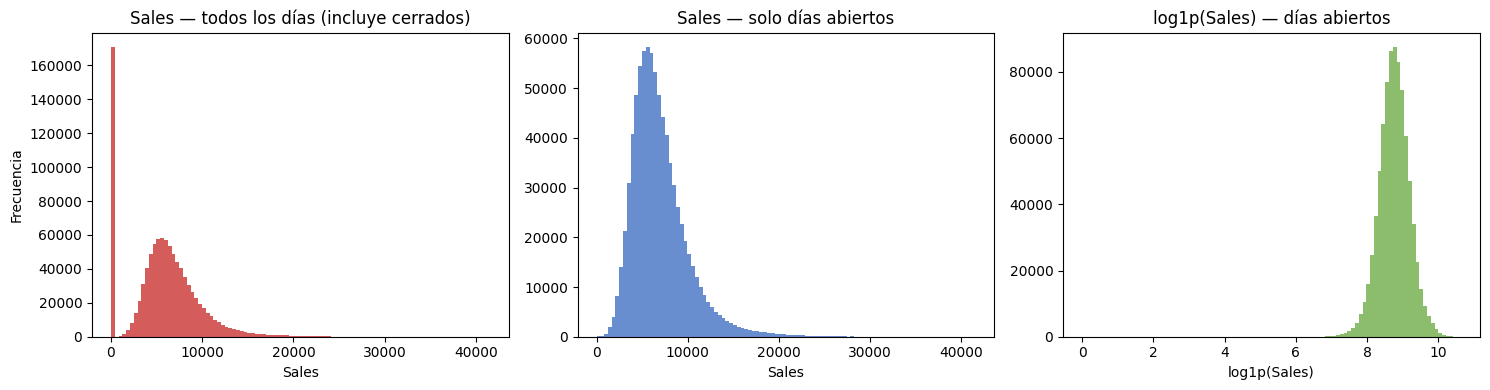

Días con tienda cerrada (Open=0): 170,627 (17.0 %)
Días cerrados con Sales > 0:      0

Estadísticas de Sales (días abiertos):


,count,mean,std,min,25%,50%,75%,max
Sales,830972.000,6955.469,3106.186,0.000,4858.000,6368.000,8360.000,41551.000


In [24]:
train_abierto = train_full[train_full["Open"] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_full["Sales"], bins=100, color="#CA3532", alpha=0.8)
axes[0].set_title("Sales — todos los días (incluye cerrados)")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(train_abierto["Sales"], bins=100, color="#4472C4", alpha=0.8)
axes[1].set_title("Sales — solo días abiertos")
axes[1].set_xlabel("Sales")

axes[2].hist(np.log1p(train_abierto["Sales"]), bins=100, color="#70AD47", alpha=0.8)
axes[2].set_title("log1p(Sales) — días abiertos")
axes[2].set_xlabel("log1p(Sales)")

plt.tight_layout()
plt.show()

n_cerrados = (train_full["Open"] == 0).sum()
n_cerrados_con_ventas = ((train_full["Open"] == 0) & (train_full["Sales"] > 0)).sum()
print(f"Días con tienda cerrada (Open=0): {n_cerrados:,} ({n_cerrados / len(train_full)*100:.1f} %)")
print(f"Días cerrados con Sales > 0:      {n_cerrados_con_ventas}")
print(f"\nEstadísticas de Sales (días abiertos):")
display(train_abierto["Sales"].describe().to_frame().T)

### **5.2 Patrones temporales: día de semana y mes**

Se analiza si las ventas presentan estacionalidad semanal y mensual clara, ya que esto justifica incluir `DayOfWeek` y `Month` como entradas exógenas al modelo.

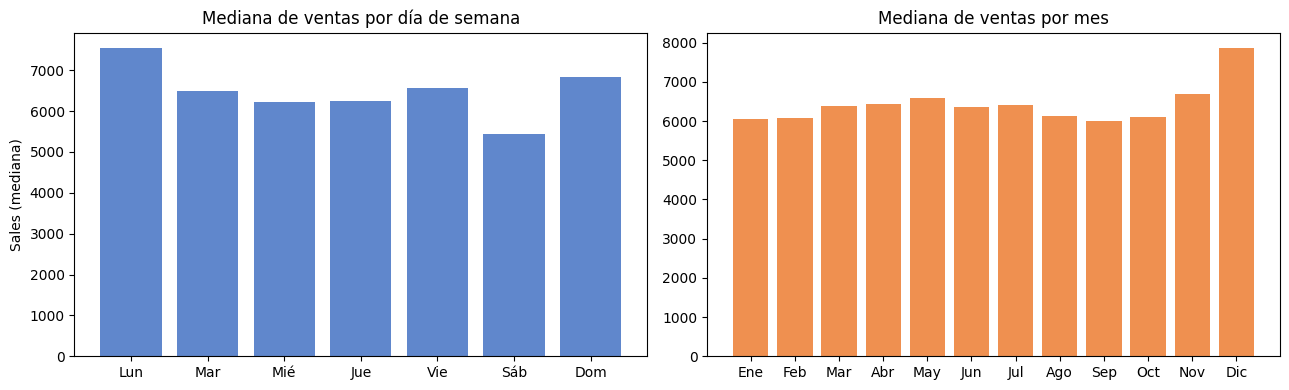

Variación día-semana (max/min): 1.39
Variación mensual  (max/min): 1.31


In [25]:
dias_semana_labels = {1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"}
meses_labels = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
                7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ventas_dia = train_abierto.groupby("DayOfWeek")["Sales"].median()
axes[0].bar(
    [dias_semana_labels[d] for d in ventas_dia.index],
    ventas_dia.values,
    color="#4472C4", alpha=0.85,
)
axes[0].set_title("Mediana de ventas por día de semana")
axes[0].set_ylabel("Sales (mediana)")

ventas_mes = train_abierto.groupby("Month")["Sales"].median()
axes[1].bar(
    [meses_labels[m] for m in ventas_mes.index],
    ventas_mes.values,
    color="#ED7D31", alpha=0.85,
)
axes[1].set_title("Mediana de ventas por mes")

plt.tight_layout()
plt.show()

print("Variación día-semana (max/min):", round(ventas_dia.max() / ventas_dia.min(), 2))
print("Variación mensual  (max/min):", round(ventas_mes.max() / ventas_mes.min(), 2))

### **5.3 Tipo de tienda, surtido y efecto de las promociones**

Se compara la distribución de ventas entre categorías de tienda y se cuantifica el impacto de `Promo` y `Promo2ActiveMonth` para confirmar su relevancia como entradas al modelo.

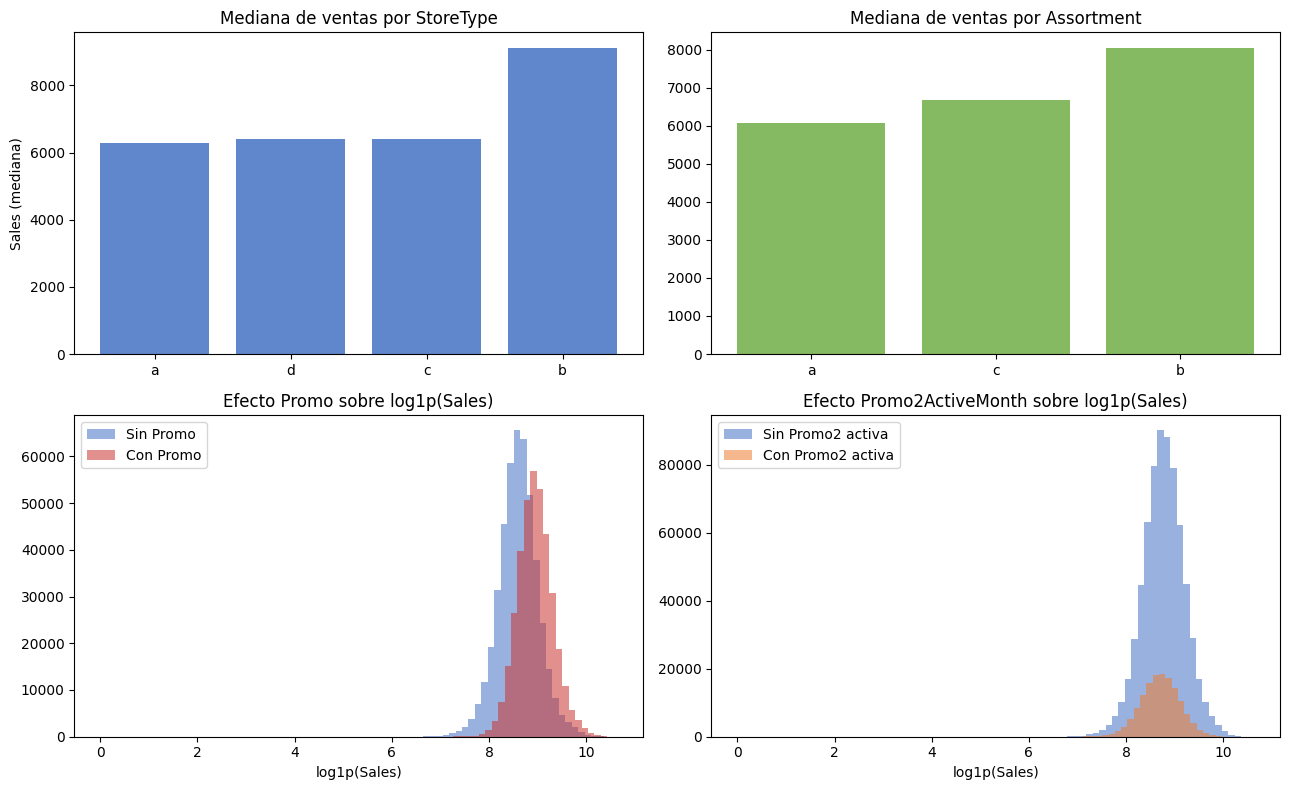

Incremento mediano Promo:             +40.1%
Incremento mediano Promo2ActiveMonth: +-6.3%


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Ventas por StoreType
mediana_storetype = train_abierto.groupby("StoreType")["Sales"].median().sort_values()
axes[0, 0].bar(mediana_storetype.index, mediana_storetype.values, color="#4472C4", alpha=0.85)
axes[0, 0].set_title("Mediana de ventas por StoreType")
axes[0, 0].set_ylabel("Sales (mediana)")

# Ventas por Assortment
mediana_assort = train_abierto.groupby("Assortment")["Sales"].median().sort_values()
axes[0, 1].bar(mediana_assort.index, mediana_assort.values, color="#70AD47", alpha=0.85)
axes[0, 1].set_title("Mediana de ventas por Assortment")

# Efecto Promo
for promo_val, label, color in [(0, "Sin Promo", "#4472C4"), (1, "Con Promo", "#CA3532")]:
    axes[1, 0].hist(
        np.log1p(train_abierto[train_abierto["Promo"] == promo_val]["Sales"]),
        bins=80, alpha=0.55, label=label, color=color,
    )
axes[1, 0].set_title("Efecto Promo sobre log1p(Sales)")
axes[1, 0].set_xlabel("log1p(Sales)")
axes[1, 0].legend()

# Efecto Promo2ActiveMonth
for val, label, color in [(0, "Sin Promo2 activa", "#4472C4"), (1, "Con Promo2 activa", "#ED7D31")]:
    axes[1, 1].hist(
        np.log1p(train_abierto[train_abierto["Promo2ActiveMonth"] == val]["Sales"]),
        bins=80, alpha=0.55, label=label, color=color,
    )
axes[1, 1].set_title("Efecto Promo2ActiveMonth sobre log1p(Sales)")
axes[1, 1].set_xlabel("log1p(Sales)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

incr_promo = (train_abierto[train_abierto["Promo"]==1]["Sales"].median() /
              train_abierto[train_abierto["Promo"]==0]["Sales"].median() - 1) * 100
incr_promo2 = (train_abierto[train_abierto["Promo2ActiveMonth"]==1]["Sales"].median() /
               train_abierto[train_abierto["Promo2ActiveMonth"]==0]["Sales"].median() - 1) * 100
print(f"Incremento mediano Promo:             +{incr_promo:.1f}%")
print(f"Incremento mediano Promo2ActiveMonth: +{incr_promo2:.1f}%")

### **5.4 Variables de competencia y distribuciones numéricas**

Se analiza la forma de las distribuciones de `CompetitionDistance`, `CompetitionOpenMonths`, `Customers` y `Promo2Weeks` para decidir si alguna requiere transformación logarítmica adicional antes del escalado.

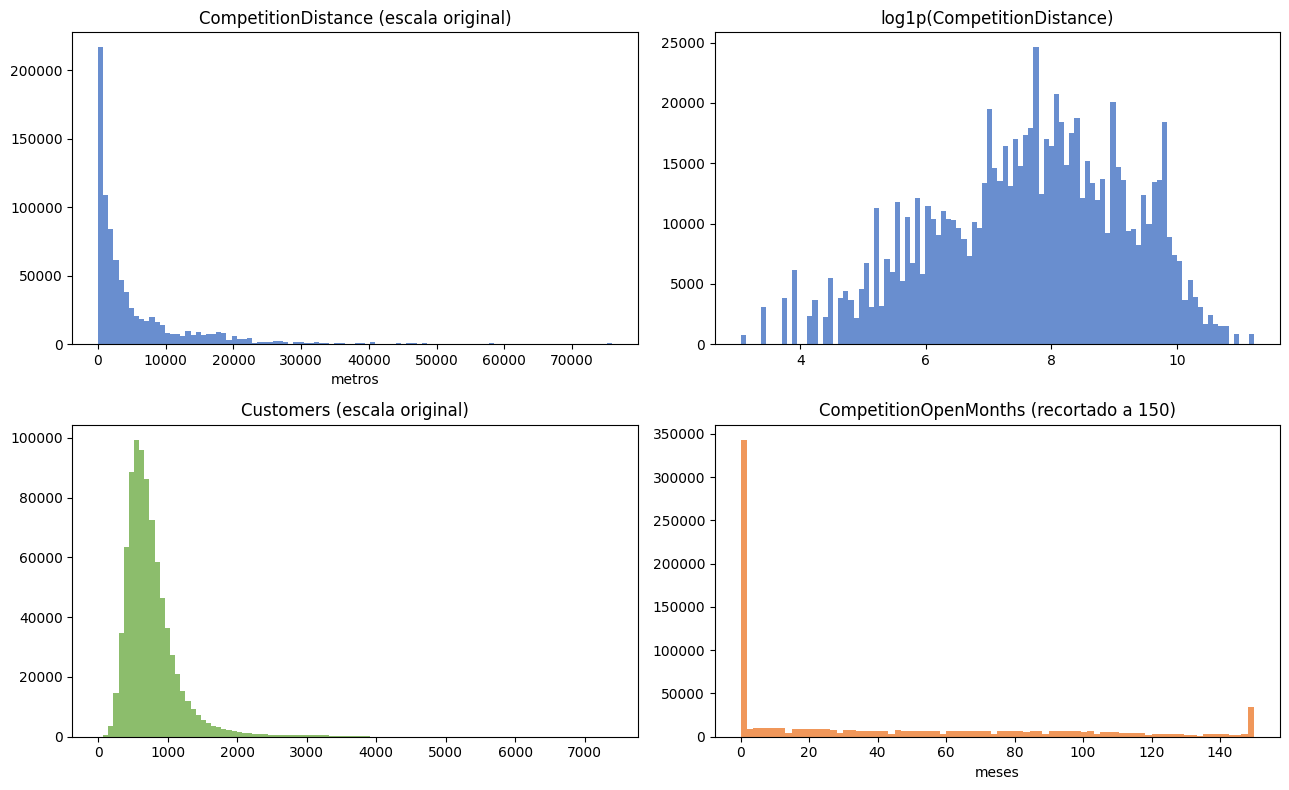

Resumen CompetitionDistance:


,count,mean,std,min,25%,50%,75%,max
CompetitionDistance,830972.000,5450.337,7801.741,20.000,710.000,2330.000,6880.000,75860.000



Resumen Customers:


,count,mean,std,min,25%,50%,75%,max
Customers,830972.000,763.342,401.616,0.000,519.000,676.000,893.000,7388.000


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(train_abierto["CompetitionDistance"], bins=100, color="#4472C4", alpha=0.8)
axes[0, 0].set_title("CompetitionDistance (escala original)")
axes[0, 0].set_xlabel("metros")

axes[0, 1].hist(np.log1p(train_abierto["CompetitionDistance"]), bins=100, color="#4472C4", alpha=0.8)
axes[0, 1].set_title("log1p(CompetitionDistance)")

axes[1, 0].hist(train_abierto["Customers"], bins=100, color="#70AD47", alpha=0.8)
axes[1, 0].set_title("Customers (escala original)")

axes[1, 1].hist(train_abierto["CompetitionOpenMonths"].clip(0, 150), bins=80, color="#ED7D31", alpha=0.8)
axes[1, 1].set_title("CompetitionOpenMonths (recortado a 150)")
axes[1, 1].set_xlabel("meses")

plt.tight_layout()
plt.show()

print("Resumen CompetitionDistance:")
display(train_abierto["CompetitionDistance"].describe().to_frame().T)
print("\nResumen Customers:")
display(train_abierto["Customers"].describe().to_frame().T)

### **5.5 Correlación entre variables numéricas**

Un mapa de calor permite detectar correlaciones fuertes entre predictores y confirmar cuáles están más relacionados con las ventas.

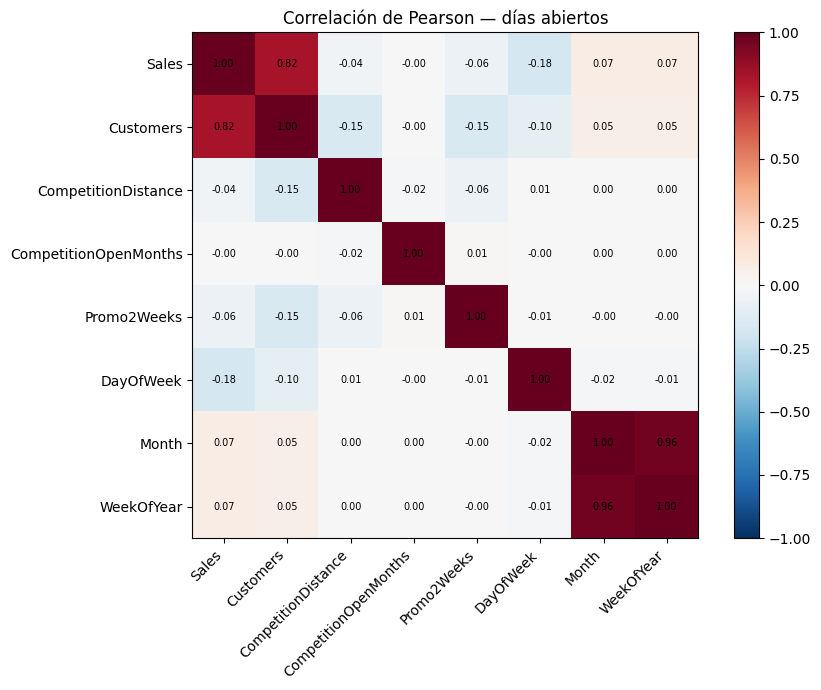

In [28]:
columnas_correlacion = [
    "Sales", "Customers", "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2Weeks", "DayOfWeek", "Month", "WeekOfYear",
]

corr = train_abierto[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_correlacion)))
ax.set_yticks(range(len(columnas_correlacion)))
ax.set_xticklabels(columnas_correlacion, rotation=45, ha="right")
ax.set_yticklabels(columnas_correlacion)
plt.colorbar(im, ax=ax)

for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

ax.set_title("Correlación de Pearson — días abiertos")
plt.tight_layout()
plt.show()

### **Conclusiones del EDA**

El análisis exploratorio arroja las siguientes observaciones que guiarán directamente las decisiones de preprocesado y modelado:

| Observación | Implicación para el modelo |
|---|---|
| `Sales` fuertemente asimétrica a la derecha | Aplicar `log1p` al target y a la columna Sales en la ventana temporal |
| ~10 % de días con tienda cerrada (Sales = 0) | Los ceros son estructurales, no outliers; el modelo debe verlos en el historial |
| Estacionalidad semanal pronunciada (~2× entre días) | `DayOfWeek` es una entrada exógena relevante; justifica usar embedding |
| Estacionalidad mensual moderada | `Month` útil como entrada exógena; ciclos de ~1 año visibles |
| `StoreType` produce diferencias grandes entre grupos | Justifica embedding de tienda para capturar la identidad de cada una |
| `Promo` incrementa ventas medianas ~20-25 % | Variable exógena de alta señal; debe incluirse en la ventana temporal |
| `CompetitionDistance` muy sesgada → log1p la normaliza | Se aplicará `log1p` antes del StandardScaler |
| `Customers` altamente correlada con `Sales` | Entrada exógena de alta señal (disponible en `test.csv`) |

## <font color="#CA3532"> **6. Escalado**</font>

Las conclusiones del EDA determinan la estrategia de escalado:

1. **`log1p`** sobre `Sales` (target `y` y columna Sales en `X_temporal`) y sobre `CompetitionDistance` en la ventana.
2. **`StandardScaler`** sobre el resto de columnas continuas, ajustado exclusivamente sobre entrenamiento para evitar fuga de información.
3. **Sin escalar**: variables binarias (`Open`, `Promo`, `SchoolHoliday`, `Promo2ActiveMonth`) y códigos categóricos para embeddings.

### **6.1 Transformación log1p sobre el target y Sales en la ventana**

In [29]:
IDX_SALES = columnas_temporales_ventana.index("Sales")
IDX_COMP_DIST = columnas_temporales_ventana.index("CompetitionDistance")

X_temporal_train_sc = X_temporal_train.copy()
X_temporal_val_sc   = X_temporal_val.copy()

# log1p en Sales (endógena en la ventana)
X_temporal_train_sc[:, :, IDX_SALES] = np.log1p(X_temporal_train_sc[:, :, IDX_SALES])
X_temporal_val_sc[:, :, IDX_SALES]   = np.log1p(X_temporal_val_sc[:, :, IDX_SALES])

# log1p en CompetitionDistance (muy sesgada según EDA)
X_temporal_train_sc[:, :, IDX_COMP_DIST] = np.log1p(X_temporal_train_sc[:, :, IDX_COMP_DIST])
X_temporal_val_sc[:, :, IDX_COMP_DIST]   = np.log1p(X_temporal_val_sc[:, :, IDX_COMP_DIST])

# log1p en target
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f"y_train original — media: {y_train.mean():.1f}, std: {y_train.std():.1f}")
print(f"y_train log1p    — media: {y_train_log.mean():.3f}, std: {y_train_log.std():.3f}")

y_train original — media: 5228.3, std: 3229.5
y_train log1p    — media: 7.192, std: 3.289


### **6.2 StandardScaler sobre columnas continuas de X_temporal**

In [30]:
from sklearn.preprocessing import StandardScaler

# Columnas binarias que NO se escalan (ya en rango [0,1])
COLS_BINARIAS = {"Open", "Promo", "SchoolHoliday", "Promo2ActiveMonth"}

# Índices de columnas continuas en X_temporal (después de log1p ya aplicado)
idx_continuas_temporal = [
    i for i, col in enumerate(columnas_temporales_ventana)
    if col not in COLS_BINARIAS
]
nombres_continuas_temporal = [columnas_temporales_ventana[i] for i in idx_continuas_temporal]

n_train, lb, _ = X_temporal_train_sc.shape
n_val = X_temporal_val_sc.shape[0]

scaler_temporal = StandardScaler()
scaler_temporal.fit(
    X_temporal_train_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
)

X_temporal_train_sc[:, :, idx_continuas_temporal] = scaler_temporal.transform(
    X_temporal_train_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
).reshape(n_train, lb, len(idx_continuas_temporal))

X_temporal_val_sc[:, :, idx_continuas_temporal] = scaler_temporal.transform(
    X_temporal_val_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
).reshape(n_val, lb, len(idx_continuas_temporal))

print(f"Columnas escaladas en X_temporal ({len(idx_continuas_temporal)}):")
print(nombres_continuas_temporal)

Columnas escaladas en X_temporal (9):
['Sales', 'Customers', 'CompetitionDistance', 'CompetitionOpenMonths', 'Promo2Weeks', 'DayOfWeek', 'Month', 'WeekOfYear', 'DayOfYear']


### **6.3 StandardScaler sobre columnas continuas de X_estatico**

In [31]:
# Los primeros 4 campos de X_estatico son códigos para embeddings -> no escalar.
# CompetitionOpen y Promo2 son binarias -> tampoco se escalan.
COLS_EMBEDDING_ESTATICO = {"StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode"}
COLS_BINARIAS_ESTATICO = {"CompetitionOpen", "Promo2"}

idx_continuas_estatico = [
    i for i, col in enumerate(columnas_estaticas_ventana)
    if col not in COLS_EMBEDDING_ESTATICO and col not in COLS_BINARIAS_ESTATICO
]
nombres_continuas_estatico = [columnas_estaticas_ventana[i] for i in idx_continuas_estatico]

X_estatico_train_sc = X_estatico_train.copy()
X_estatico_val_sc   = X_estatico_val.copy()

scaler_estatico = StandardScaler()
scaler_estatico.fit(X_estatico_train_sc[:, idx_continuas_estatico])

X_estatico_train_sc[:, idx_continuas_estatico] = scaler_estatico.transform(
    X_estatico_train_sc[:, idx_continuas_estatico]
)
X_estatico_val_sc[:, idx_continuas_estatico] = scaler_estatico.transform(
    X_estatico_val_sc[:, idx_continuas_estatico]
)

print(f"Columnas escaladas en X_estatico ({len(idx_continuas_estatico)}): {nombres_continuas_estatico}")
print(f"Códigos para embeddings (sin escalar): {sorted(COLS_EMBEDDING_ESTATICO)}")
print(f"Binarias estáticas (sin escalar): {sorted(COLS_BINARIAS_ESTATICO)}")

Columnas escaladas en X_estatico (1): ['CompetitionDistance']
Códigos para embeddings (sin escalar): ['AssortmentCode', 'PromoIntervalCode', 'StoreCode', 'StoreTypeCode']
Binarias estáticas (sin escalar): ['CompetitionOpen', 'Promo2']


### **6.4 Verificación: arrays listos para el modelo**

In [32]:
resumen_arrays = pd.DataFrame({
    "array": [
        "X_temporal_train_sc", "X_temporal_val_sc",
        "X_estatico_train_sc", "X_estatico_val_sc",
        "y_train_log",         "y_val_log",
    ],
    "shape": [
        X_temporal_train_sc.shape, X_temporal_val_sc.shape,
        X_estatico_train_sc.shape, X_estatico_val_sc.shape,
        y_train_log.shape,         y_val_log.shape,
    ],
    "media": [
        float(X_temporal_train_sc.mean()), float(X_temporal_val_sc.mean()),
        float(X_estatico_train_sc.mean()), float(X_estatico_val_sc.mean()),
        float(y_train_log.mean()),         float(y_val_log.mean()),
    ],
    "std": [
        float(X_temporal_train_sc.std()), float(X_temporal_val_sc.std()),
        float(X_estatico_train_sc.std()), float(X_estatico_val_sc.std()),
        float(y_train_log.std()),         float(y_val_log.std()),
    ],
})
display(resumen_arrays)
print("\nTodos los arrays están listos para ser usados como entradas del modelo neuronal.")

,array,shape,media,std
0,X_temporal_train_sc,"(8580, 28, 13)",0.113,0.890
1,X_temporal_val_sc,"(420, 28, 13)",0.122,0.784
2,X_estatico_train_sc,"(8580, 7)",71.043,213.643
3,X_estatico_val_sc,"(420, 7)",71.043,213.643
4,y_train_log,"(8580,)",7.192,3.289
5,y_val_log,"(420,)",7.451,3.063



Todos los arrays están listos para ser usados como entradas del modelo neuronal.


## <font color="#CA3532"> **7. Baseline persistente**</font>

Antes de entrenar una red neuronal, se define un modelo de referencia sencillo. En series de ventas diarias suele ser razonable usar una persistencia semanal:

\[
Sales(t) = Sales(t-7)
\]

Este baseline permite comprobar si los modelos neuronales aportan mejora real frente a una regla simple basada en el patrón semanal.

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def calcular_metricas(y_real, y_pred, nombre):
    return {
        "modelo": nombre,
        "R2": r2_score(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
    }

### **7.1 Predicción persistente a 1 día y a 7 días**

Se calculan dos referencias: una persistencia diaria (`t-1`) y una persistencia semanal (`t-7`). La semanal suele ser más fuerte en este problema porque las ventas dependen mucho del día de la semana.

In [34]:
if lookback < 7:
    raise ValueError("El baseline semanal necesita lookback >= 7")

idx_sales = columnas_temporales_ventana.index("Sales")

pred_persistente_1d = X_temporal[:, -1, idx_sales]
pred_persistente_7d = X_temporal[:, -7, idx_sales]

mascara_train_np = mascara_train.to_numpy()
mascara_val_np = mascara_val.to_numpy()

pred_persistente_1d_train = pred_persistente_1d[mascara_train_np]
pred_persistente_1d_val = pred_persistente_1d[mascara_val_np]
pred_persistente_7d_train = pred_persistente_7d[mascara_train_np]
pred_persistente_7d_val = pred_persistente_7d[mascara_val_np]

print("pred_persistente_1d_val:", pred_persistente_1d_val.shape)
print("pred_persistente_7d_val:", pred_persistente_7d_val.shape)

pred_persistente_1d_val: (420,)
pred_persistente_7d_val: (420,)


### **7.2 Métricas del baseline**

In [35]:
metricas_baseline = pd.DataFrame([
    calcular_metricas(y_train, pred_persistente_1d_train, "Persistente 1 día - train"),
    calcular_metricas(y_val, pred_persistente_1d_val, "Persistente 1 día - validación"),
    calcular_metricas(y_train, pred_persistente_7d_train, "Persistente 7 días - train"),
    calcular_metricas(y_val, pred_persistente_7d_val, "Persistente 7 días - validación"),
])

metricas_baseline

,modelo,R2,RMSE,MAE
0,Persistente 1 día - train,-0.618,4108.347,2707.583
1,Persistente 1 día - validación,-0.417,3829.916,2466.605
2,Persistente 7 días - train,0.326,2651.776,1791.672
3,Persistente 7 días - validación,0.475,2331.453,1753.198


**Lectura del baseline.** El persistente a **1 día fracasa** (R² = −0,42 en validación, peor que
predecir la media) porque arrastra los ceros del cierre dominical: predice el lunes con el 0 del
domingo. El persistente a **7 días** respeta el ciclo semanal (copia el mismo día de la
semana anterior) y alcanza **R² = 0,475**: esta es la **referencia honesta a batir** por el modelo
neuronal — cualquier arquitectura que no supere 0,475 no está aprendiendo nada útil.

### **7.3 Comparación visual en validación**

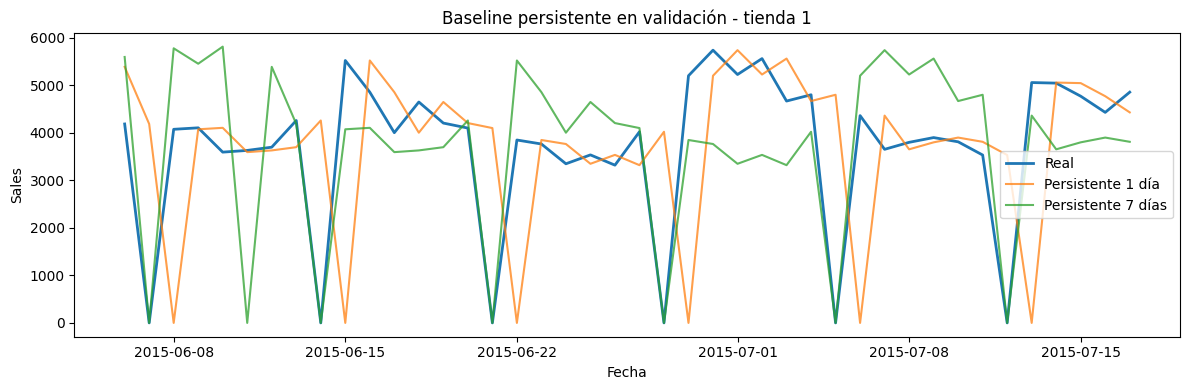

,Store,Date,Sales_real,Baseline_1d,Baseline_7d
858,1,2015-06-06,4183.000,5384.000,5592.000
859,1,2015-06-07,0.000,4183.000,0.000
860,1,2015-06-08,4071.000,0.000,5774.000
861,1,2015-06-09,4102.000,4071.000,5450.000
862,1,2015-06-10,3591.000,4102.000,5809.000


In [36]:
comparacion_val = metadatos_ventanas.loc[mascara_val_np].copy()
comparacion_val["Sales_real"] = y_val
comparacion_val["Baseline_1d"] = pred_persistente_1d_val
comparacion_val["Baseline_7d"] = pred_persistente_7d_val

tienda_grafica = comparacion_val["Store"].iloc[0]
datos_grafica = comparacion_val[comparacion_val["Store"] == tienda_grafica].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(datos_grafica["Date"], datos_grafica["Sales_real"], label="Real", linewidth=2)
plt.plot(datos_grafica["Date"], datos_grafica["Baseline_1d"], label="Persistente 1 día", alpha=0.75)
plt.plot(datos_grafica["Date"], datos_grafica["Baseline_7d"], label="Persistente 7 días", alpha=0.75)
plt.title(f"Baseline persistente en validación - tienda {tienda_grafica}")
plt.xlabel("Fecha")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

display(comparacion_val.head())

## <font color='#CA3532'>**8. Modelo neuronal con entradas heterogéneas**</font>

El baseline persistente a 7 días (sección 7) alcanza un R² ≈ 0,47: una referencia razonable pero
mejorable. Construimos ahora el modelo que da sentido a la práctica, una red **funcional** que
combina las tres naturalezas de entrada:

- **Rama recurrente (GRU)** sobre la ventana temporal de ventas y exógenas pasadas.
- **Embeddings** para las categóricas de tienda (`Store`, `StoreType`, `Assortment`, `PromoInterval`).
- **Rama numérica** para las estáticas continuas/binarias.

**Mejora clave respecto al enventanado de la sección 4:** añadimos las **exógenas del día objetivo**
(el `DayOfWeek`, `Promo`, `Open`, `StateHoliday` y la estacionalidad **del día que se predice**). Sin
ellas el modelo "no sabe qué día predice" y un baseline semanal lo supera. Reutilizamos el
`train_full` y las `cardinalidades_embedding` ya preparados en las secciones 2-3.

In [37]:
set_random_seed(7)

# En True ejecuta una versión reducida (10 tiendas, pocas épocas) para validar el flujo.
MODO_RAPIDO_MODELO = False

### **8.1 Enventanado enriquecido (con exógenas del día objetivo)**

In [38]:
# 13 variables temporales (las mismas de la sección 4) para la rama recurrente
COLS_TEMPORALES = [
    "Sales", "Customers", "Open", "Promo", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpenMonths", "Promo2Weeks", "Promo2ActiveMonth",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]
# 7 atributos estáticos de tienda (4 códigos para embeddings + 3 numéricas)
COLS_ESTATICAS = [
    "StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode",
    "CompetitionDistance", "CompetitionOpen", "Promo2",
]
# Exógenas CONOCIDAS del día objetivo (+ Customers, que solo usa la variante con leakage)
COLS_OBJETIVO_BASE = [
    "DayOfWeekCode", "StateHolidayCode", "Promo", "Open", "SchoolHoliday", "DayOfYear", "Customers",
]
IDX_SALES_T = COLS_TEMPORALES.index("Sales")
LOOKBACK = 28


def construir_ventanas(df, lookback=28, horizonte=1, tiendas=None):
    # Ventanas por tienda: ventana temporal (Xt), estáticas (Xe), exógenas del día objetivo (Xo)
    # y target. Descarta las ventanas que cruzan huecos de fechas.
    if tiendas is not None:
        df = df[df["Store"].isin(tiendas)]
    df = df.sort_values(["Store", "Date"])
    span = np.timedelta64(lookback - 1 + horizonte, "D")
    Xt_l, Xe_l, Xo_l, y_l, open_l, store_l, fecha_l = [], [], [], [], [], [], []
    descartadas = 0
    for store_id, g in df.groupby("Store", sort=True):
        n = len(g); k = n - lookback - horizonte + 1
        if k <= 0:
            continue
        arr_t = g[COLS_TEMPORALES].to_numpy(np.float32)
        arr_e = g[COLS_ESTATICAS].to_numpy(np.float32)
        arr_o = g[COLS_OBJETIVO_BASE].to_numpy(np.float32)
        fechas = g["Date"].to_numpy()
        ventanas = sliding_window_view(arr_t, lookback, axis=0).transpose(0, 2, 1)[:k]
        idx_obj = np.arange(lookback + horizonte - 1, n)
        ok = (fechas[idx_obj] - fechas[:k]) == span      # la ventana abarca días contiguos
        descartadas += int((~ok).sum())
        if not ok.any():
            continue
        doy = arr_o[idx_obj, 5]
        xo = np.column_stack([
            arr_o[idx_obj, 0], arr_o[idx_obj, 1], arr_o[idx_obj, 2], arr_o[idx_obj, 3], arr_o[idx_obj, 4],
            np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25), arr_o[idx_obj, 6],
        ]).astype(np.float32)
        Xt_l.append(ventanas[ok]); Xe_l.append(arr_e[idx_obj][ok]); Xo_l.append(xo[ok])
        y_l.append(arr_t[idx_obj, IDX_SALES_T][ok]); open_l.append(arr_o[idx_obj, 3][ok])
        store_l.append(np.full(int(ok.sum()), store_id, np.int32)); fecha_l.append(fechas[idx_obj][ok])
    return {"Xt": np.concatenate(Xt_l), "Xe": np.concatenate(Xe_l), "Xo": np.concatenate(Xo_l),
            "y": np.concatenate(y_l), "open": np.concatenate(open_l),
            "meta": pd.DataFrame({"Store": np.concatenate(store_l),
                                  "DateObjetivo": pd.to_datetime(np.concatenate(fecha_l))}),
            "descartadas": descartadas}

print("Funciones de enventanado listas. Variables del día objetivo:", COLS_OBJETIVO_BASE)

Funciones de enventanado listas. Variables del día objetivo: ['DayOfWeekCode', 'StateHolidayCode', 'Promo', 'Open', 'SchoolHoliday', 'DayOfYear', 'Customers']


### **8.2 Escalado y arquitectura parametrizada**

`log1p` en las variables sesgadas (`Sales`, `Customers`, `CompetitionDistance`) y `StandardScaler`
en las continuas, con estadísticos ajustados **solo en entrenamiento**. La función `crear_modelo`
permite construir cualquier variante (GRU/LSTM, apilada, con/sin embeddings, con/sin día objetivo,
con/sin `Customers`), de modo que toda la comparación use el mismo código.

In [39]:
IDX_LOG_T  = [COLS_TEMPORALES.index(c) for c in ["Sales", "Customers", "CompetitionDistance"]]
IDX_BIN_T  = {COLS_TEMPORALES.index(c) for c in ["Open", "Promo", "SchoolHoliday", "Promo2ActiveMonth"]}
IDX_CONT_T = [i for i in range(len(COLS_TEMPORALES)) if i not in IDX_BIN_T]
IDX_DIST_E = COLS_ESTATICAS.index("CompetitionDistance")
IDX_CUST_O = 7


def _ajustar_escalar(V, mask):
    Xt, Xe, Xo = V["Xt"], V["Xe"], V["Xo"]; params = {"t": {}}
    for i in IDX_LOG_T:
        np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
    for i in IDX_CONT_T:
        v = Xt[mask, :, i]; mu, sd = float(v.mean()), float(v.std() + 1e-8)
        Xt[:, :, i] = (Xt[:, :, i] - mu) / sd; params["t"][i] = (mu, sd)
    np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
    mu, sd = float(Xe[mask, IDX_DIST_E].mean()), float(Xe[mask, IDX_DIST_E].std()+1e-8)
    Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E]-mu)/sd; params["e"] = (mu, sd)
    np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
    mu, sd = float(Xo[mask, IDX_CUST_O].mean()), float(Xo[mask, IDX_CUST_O].std()+1e-8)
    Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O]-mu)/sd; params["o"] = (mu, sd)
    return params


def aplicar_escalado(params, Xt, Xe, Xo):
    for i in IDX_LOG_T:
        np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
    for i, (mu, sd) in params["t"].items():
        Xt[:, :, i] = (Xt[:, :, i]-mu)/sd
    np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
    mu, sd = params["e"]; Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E]-mu)/sd
    np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
    mu, sd = params["o"]; Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O]-mu)/sd


def preparar_datos(V, dias_validacion=42):
    corte = V["meta"]["DateObjetivo"].max() - pd.Timedelta(days=dias_validacion)
    mask_tr = (V["meta"]["DateObjetivo"] <= corte).to_numpy(); ab = V["open"] > 0
    mfit, mva = mask_tr & ab, ~mask_tr
    params = _ajustar_escalar(V, mfit)
    D = {"lookback": V["Xt"].shape[1], "params": params,
         "Xt_fit": V["Xt"][mfit], "Xe_fit": V["Xe"][mfit], "Xo_fit": V["Xo"][mfit],
         "y_fit_log": np.log1p(V["y"][mfit]),
         "Xt_vo": V["Xt"][mva & ab], "Xe_vo": V["Xe"][mva & ab], "Xo_vo": V["Xo"][mva & ab],
         "y_vo_log": np.log1p(V["y"][mva & ab]),
         "Xt_val": V["Xt"][mva], "Xe_val": V["Xe"][mva], "Xo_val": V["Xo"][mva],
         "y_val": V["y"][mva], "open_val": V["open"][mva],
         "meta_val": V["meta"].loc[mva].reset_index(drop=True)}
    print(f"corte train/val: {corte.date()} | fit (abiertos): {len(D['y_fit_log']):,} "
          f"| val: {len(D['y_val']):,}")
    return D

In [40]:
def crear_modelo(lookback, rama="gru", capas_rnn=(32,), bidireccional=False,
                 densas=(64, 32), dropouts=(0.2, 0.0), solo_endogena=False,
                 usar_estaticas=True, usar_dia_objetivo=False, usar_customers=False,
                 dim_emb_store=16, lr=1e-3):
    set_random_seed(7)
    n_feat = 1 if solo_endogena else len(COLS_TEMPORALES)
    in_t = Input(shape=(lookback, n_feat), name="temporal")
    if rama == "densa":
        r = Dense(capas_rnn[0], activation="relu")(Flatten()(in_t))
    else:
        RNN = GRU if rama == "gru" else LSTM
        x = in_t
        for i, u in enumerate(capas_rnn):
            capa = RNN(u, return_sequences=(i < len(capas_rnn) - 1),
                       name="rnn" if len(capas_rnn) == 1 else f"rnn{i}")
            x = (Bidirectional(capa) if bidireccional else capa)(x)
        r = x
    entradas, ramas = [in_t], [r]
    if usar_estaticas:
        for nombre, col, dim in [("store", "StoreCode", dim_emb_store), ("storetype", "StoreTypeCode", 2),
                                 ("assortment", "AssortmentCode", 2), ("promointerval", "PromoIntervalCode", 2)]:
            inp = Input(shape=(1,), name=nombre); entradas.append(inp)
            ramas.append(Flatten()(Embedding(cardinalidades_embedding[col], dim, name=f"emb_{nombre}")(inp)))
        in_num = Input(shape=(3,), name="numerico"); entradas.append(in_num); ramas.append(in_num)
    if usar_dia_objetivo:
        in_dow = Input(shape=(1,), name="dow_obj"); entradas.append(in_dow)
        ramas.append(Flatten()(Embedding(cardinalidades_embedding["DayOfWeekCode"], 3, name="emb_dow_obj")(in_dow)))
        in_fes = Input(shape=(1,), name="festivo_obj"); entradas.append(in_fes)
        ramas.append(Flatten()(Embedding(cardinalidades_embedding["StateHolidayCode"], 2, name="emb_festivo_obj")(in_fes)))
        in_ex = Input(shape=(5,), name="exog_obj"); entradas.append(in_ex); ramas.append(in_ex)
    if usar_customers:
        in_c = Input(shape=(1,), name="customers_obj"); entradas.append(in_c); ramas.append(in_c)
    x = concatenate(ramas) if len(ramas) > 1 else ramas[0]
    for u, dr in zip(densas, dropouts):
        x = Dense(u, activation="relu")(x)
        if dr > 0:
            x = Dropout(dr)(x)
    salida = Dense(1, name="sales_log")(x)
    m = Model(entradas, salida)
    m.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr), metrics=["mae"])
    return m


def construir_xs(Xt, Xe, Xo, solo_endogena=False, usar_estaticas=True,
                 usar_dia_objetivo=False, usar_customers=False, **_):
    d = {"temporal": Xt[:, :, [IDX_SALES_T]] if solo_endogena else Xt}
    if usar_estaticas:
        for j, nombre in enumerate(["store", "storetype", "assortment", "promointerval"]):
            d[nombre] = Xe[:, j:j+1].astype("int32")
        d["numerico"] = Xe[:, 4:7].astype("float32")
    if usar_dia_objetivo:
        d["dow_obj"] = Xo[:, 0:1].astype("int32"); d["festivo_obj"] = Xo[:, 1:2].astype("int32")
        d["exog_obj"] = Xo[:, 2:7].astype("float32")
    if usar_customers:
        d["customers_obj"] = Xo[:, 7:8].astype("float32")
    return d


def predecir_real(modelo, Xs, open_obj):
    p = np.expm1(np.clip(modelo.predict(Xs, batch_size=4096, verbose=0).ravel(), 0.0, 12.5))
    p[open_obj <= 0] = 0.0
    return p


def fila_metricas(nombre, y_real, pred, open_obj):
    ab = open_obj > 0
    return {"modelo": nombre, "R2_total": r2_score(y_real, pred),
            "R2_abiertas": r2_score(y_real[ab], pred[ab]),
            "RMSE": float(np.sqrt(mean_squared_error(y_real, pred))),
            "MAE": float(mean_absolute_error(y_real, pred))}


def ejecutar_experimento(nombre, cfg, D, epochs=80, batch=128, paciencia=10, verbose=0):
    t0 = time.time(); modelo = crear_modelo(D["lookback"], **cfg)
    Xs_fit = construir_xs(D["Xt_fit"], D["Xe_fit"], D["Xo_fit"], **cfg)
    Xs_vo = construir_xs(D["Xt_vo"], D["Xe_vo"], D["Xo_vo"], **cfg)
    cbs = [EarlyStopping(monitor="val_loss", patience=paciencia, restore_best_weights=True),
           ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, paciencia//2-1), min_lr=1e-6)]
    h = modelo.fit(Xs_fit, D["y_fit_log"], validation_data=(Xs_vo, D["y_vo_log"]),
                   epochs=epochs, batch_size=batch, callbacks=cbs, verbose=verbose)
    pred = predecir_real(modelo, construir_xs(D["Xt_val"], D["Xe_val"], D["Xo_val"], **cfg), D["open_val"])
    fila = fila_metricas(nombre, D["y_val"], pred, D["open_val"])
    fila["epocas"] = len(h.history["loss"]); fila["minutos"] = round((time.time()-t0)/60, 1)
    print(f"{nombre}: R2_total={fila['R2_total']:.3f} | R2_abiertas={fila['R2_abiertas']:.3f} "
          f"| {fila['epocas']} épocas | {fila['minutos']} min")
    return modelo, h, fila, pred


diario_ventas = train_full[["Store", "Date", "Sales"]]

def baseline_persistencia(D, dias, nombre):
    ref = D["meta_val"][["Store", "DateObjetivo"]].copy()
    ref["DateRef"] = ref["DateObjetivo"] - pd.Timedelta(days=dias)
    m = ref.merge(diario_ventas.rename(columns={"Date": "DateRef", "Sales": "Pred"}),
                  on=["Store", "DateRef"], how="left")
    pred = m["Pred"].to_numpy("float32")
    if np.isnan(pred).any():
        pred = np.nan_to_num(pred, nan=float(np.nanmedian(pred)))
    pred[D["open_val"] <= 0] = 0.0
    fila = fila_metricas(nombre, D["y_val"], pred, D["open_val"]); fila["epocas"], fila["minutos"] = 0, 0.0
    return fila, pred

## <font color='#CA3532'>**9. Comparación de arquitecturas (10 tiendas, horizonte 1)**</font>

Para aislar la aportación de cada componente comparamos varias arquitecturas sobre las 10 tiendas de
desarrollo y horizonte 1. La progresión de los diferentes modelos (M1→M2→M3) muestra el valor de cada ingrediente.

- **M0**: Red neuronal densa (sin recurrencia). 
- **M1**: GRU solo endógena.
- **M2**: GRU + embeddings de tienda. 
- **M3**: M2 + exógenas del día objetivo.
- **M4**: M3 + Customers del día.
- **M5**: LSTM (variante de M3). 


In [41]:
tiendas_dev = sorted(train_full["Store"].unique())[:10]
EPOCHS_A = 5 if MODO_RAPIDO_MODELO else 80

VA = construir_ventanas(train_full, lookback=LOOKBACK, horizonte=1, tiendas=tiendas_dev)
print(f"ventanas fase A: {len(VA['y']):,} (descartadas por huecos: {VA['descartadas']:,})")
D_A = preparar_datos(VA)

filas_A, historias_A = [], {}
for dias, nombre in [(1, "Baseline persistente 1 día"), (7, "Baseline persistente 7 días")]:
    fila, _ = baseline_persistencia(D_A, dias, nombre); filas_A.append(fila)

experimentos_A = [
    ("M0 — Densa (sin recurrencia)", dict(rama="densa", capas_rnn=(64,))),
    ("M1 — GRU solo endógena",       dict(solo_endogena=True, usar_estaticas=False)),
    ("M2 — GRU + embeddings tienda",  dict()),
    ("M3 — M2 + exógenas día objetivo", dict(usar_dia_objetivo=True)),
    ("M4 — M3 + Customers del día",   dict(usar_dia_objetivo=True, usar_customers=True)),
    ("M5 — LSTM (variante de M3)",    dict(rama="lstm", usar_dia_objetivo=True)),
]
for nombre, cfg in experimentos_A:
    _, h, fila, _ = ejecutar_experimento(nombre, cfg, D_A, epochs=EPOCHS_A, paciencia=10)
    filas_A.append(fila); historias_A[nombre] = h

ventanas fase A: 9,000 (descartadas por huecos: 0)
corte train/val: 2015-06-05 | fit (abiertos): 7,110 | val: 420
M0 — Densa (sin recurrencia): R2_total=0.466 | R2_abiertas=-0.043 | 14 épocas | 0.1 min
M1 — GRU solo endógena: R2_total=0.798 | R2_abiertas=0.606 | 42 épocas | 0.4 min
M2 — GRU + embeddings tienda: R2_total=0.837 | R2_abiertas=0.682 | 22 épocas | 0.3 min
M3 — M2 + exógenas día objetivo: R2_total=0.849 | R2_abiertas=0.705 | 20 épocas | 0.3 min
M4 — M3 + Customers del día: R2_total=0.921 | R2_abiertas=0.846 | 20 épocas | 0.3 min
M5 — LSTM (variante de M3): R2_total=0.756 | R2_abiertas=0.525 | 24 épocas | 0.3 min


,modelo,R2_total,R2_abiertas,RMSE,MAE,epocas,minutos
0,M4 — M3 + Customers del día,0.921,0.846,902.399,603.559,20,0.300
1,M3 — M2 + exógenas día objetivo,0.849,0.705,1250.758,886.110,20,0.300
2,M2 — GRU + embeddings tienda,0.837,0.682,1298.363,881.828,22,0.300
3,M1 — GRU solo endógena,0.798,0.606,1445.838,1004.565,42,0.400
4,M5 — LSTM (variante de M3),0.756,0.525,1587.932,1125.588,24,0.300
5,Baseline persistente 7 días,0.475,-0.025,2331.453,1753.198,0,0.000
6,M0 — Densa (sin recurrencia),0.466,-0.043,2351.622,1779.301,14,0.100
7,Baseline persistente 1 día,-0.047,-1.043,3291.641,1792.050,0,0.000


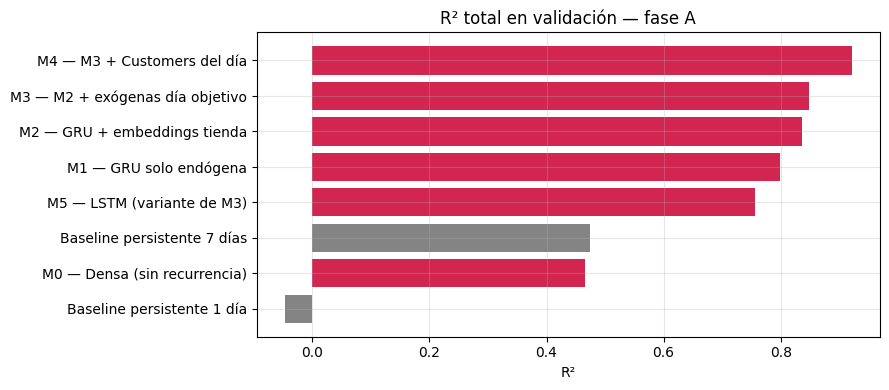

In [42]:
tabla_A = pd.DataFrame(filas_A).sort_values("R2_total", ascending=False).reset_index(drop=True)
display(tabla_A.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
orden = tabla_A.sort_values("R2_total")
ax.barh(orden["modelo"], orden["R2_total"],
        color=["#CA0032" if m.startswith("M") else "#6E6E6E" for m in orden["modelo"]], alpha=0.85)
ax.set_title("R² total en validación — fase A"); ax.set_xlabel("R²"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura de la comparación.** Tres conclusiones con los números delante:

- **La recurrencia importa:** la red densa M0 (R² = 0,466) no supera al baseline semanal (0,475);
  con una GRU incluso usando solo las ventas pasadas (M1) se sube a **0,798**.
- **Cada tipo de entrada suma:** los embeddings de tienda añaden +0,04 (M2 = 0,837), las exógenas
  del día objetivo otro salto (M3 = **0,849**, y mucho mayor en días abiertos: de 0,68 a 0,70) y
  `Customers` del día dispara a M4 = **0,921** — aunque con el asterisco del *leakage* que se
  discute en la sección 14.
- **GRU ≥ LSTM:** la variante LSTM (M5 = 0,756) no mejora a su gemela GRU (M3 = 0,849) y tiene más
  parámetros; por eso el modelo final usa GRU.

Estos resultados con 10 tiendas seleccionan la *receta* (M3/M4); su versión a escala completa se
entrena en la sección 11 con la arquitectura ganadora del barrido de la sección 10.

## <font color='#CA3532'>**10. Barrido de arquitecturas grandes (entrenamiento largo)**</font>

Tomando M3/M4 como base, se realizó un **barrido de 6 arquitecturas grandes** sobre **las 1115
tiendas** a horizonte 14, con entrenamiento largo y callbacks generosos (`EarlyStopping patience=50`,
`ReduceLROnPlateau patience=18`, hasta 500 épocas). Por su coste (~7,5 h) se ejecutó en un script
aparte que hemos adjuntado comentado a continuación; en este notebook se muestra el resumen los resultados obtenidos.

In [43]:
# """
# Barrido de arquitecturas para entrenamiento largo desatendido (~8 h).

# Variables de entorno:
#   DRY=1          -> prueba rápida (15 tiendas, 3 épocas, 2 arquitecturas) para validar el flujo
#   LIMITE_HORAS=7.5  -> tope de tiempo global; al alcanzarlo termina ordenadamente

# Salidas (carpeta entrenamiento_nocturno/):
#   resultados_nocturno.csv     tabla de métricas (se reescribe tras CADA arquitectura)
#   <nombre>.keras              mejor modelo de cada arquitectura
#   <nombre>_history.csv        curva de entrenamiento de cada arquitectura
#   entrenamiento_nocturno.log  log con marcas de tiempo
#   submission_nocturno_max.csv      submission de la mejor variante global (máximo R²)
#   submission_nocturno_realista.csv submission de la mejor variante SIN Customers
# """
# import os, gc, time, traceback
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# from pathlib import Path
# from datetime import datetime

# import numpy as np
# import pandas as pd
# from numpy.lib.stride_tricks import sliding_window_view
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# import keras
# from keras.layers import (Input, GRU, LSTM, Bidirectional, Embedding, Flatten,
#                           Dense, Dropout, concatenate)
# from keras import Model, optimizers
# from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
# from keras.utils import set_random_seed

# PROJECT = Path("/Users/emiliosanchez/Taller-B3--T5-Entradas-Heterogeneas")
# OUT_DIR = PROJECT / "entrenamiento_nocturno"
# OUT_DIR.mkdir(exist_ok=True)
# LOGFILE = OUT_DIR / "entrenamiento_nocturno.log"

# DRY = os.environ.get("DRY", "0") == "1"
# LIMITE_SEG = float(os.environ.get("LIMITE_HORAS", "7.5")) * 3600
# T0 = time.time()
# set_random_seed(7)


# def log(msg):
#     linea = f"[{datetime.now():%Y-%m-%d %H:%M:%S} | +{(time.time()-T0)/60:6.1f} min] {msg}"
#     print(linea, flush=True)
#     with open(LOGFILE, "a") as f:
#         f.write(linea + "\n")


# log(f"=== INICIO {'(DRY RUN)' if DRY else '(ENTRENAMIENTO COMPLETO)'} | "
#     f"límite {LIMITE_SEG/3600:.1f} h ===")

# # ============================================================ PREPROCESADO
# DATASET_DIR = PROJECT / "dataset_completo_Rossmann-20260604T174330Z-3-001" / "dataset_completo_Rossmann"
# train = pd.read_csv(DATASET_DIR / "train.csv", parse_dates=["Date"], low_memory=False)
# test  = pd.read_csv(DATASET_DIR / "test.csv",  parse_dates=["Date"], low_memory=False)
# store = pd.read_csv(DATASET_DIR / "store.csv", low_memory=False)
# for df_ in (train, test):
#     df_["StateHoliday"] = df_["StateHoliday"].astype(str).replace({"0.0": "0"})

# MESES_PROMO = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
#                7: "Jul", 8: "Aug", 9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec"}


# def preparar_tabla(df, mediana_distancia):
#     df = df.copy()
#     df["Year"] = df["Date"].dt.year
#     df["Month"] = df["Date"].dt.month
#     df["Day"] = df["Date"].dt.day
#     df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
#     df["DayOfYear"] = df["Date"].dt.dayofyear
#     df["CompetitionDistance"] = df["CompetitionDistance"].fillna(mediana_distancia)
#     df["PromoInterval"] = df["PromoInterval"].fillna("None")
#     for col in ["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
#                 "Promo2SinceWeek", "Promo2SinceYear"]:
#         df[col] = df[col].fillna(0)
#     hay = (df["CompetitionOpenSinceMonth"] > 0) & (df["CompetitionOpenSinceYear"] > 0)
#     meses = (df["Year"] - df["CompetitionOpenSinceYear"]) * 12 + (df["Month"] - df["CompetitionOpenSinceMonth"])
#     df["CompetitionOpen"] = hay.astype(int)
#     df["CompetitionOpenMonths"] = meses.where(hay, 0).clip(lower=0)
#     activo = (df["Promo2"] == 1) & (df["Promo2SinceWeek"] > 0) & (df["Promo2SinceYear"] > 0)
#     inicio = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
#     if activo.any():
#         codigo_iso = (df.loc[activo, "Promo2SinceYear"].astype(int).astype(str)
#                       + df.loc[activo, "Promo2SinceWeek"].astype(int).astype(str).str.zfill(2) + "1")
#         inicio.loc[activo] = pd.to_datetime(codigo_iso, format="%G%V%u", errors="coerce")
#     df["Promo2Weeks"] = ((df["Date"] - inicio).dt.days / 7.0).fillna(0).clip(lower=0)
#     mes_label = df["Month"].map(MESES_PROMO)
#     en_int = np.array([m in s for m, s in zip(mes_label, df["PromoInterval"].astype(str))])
#     df["Promo2ActiveMonth"] = (en_int & activo.to_numpy() & (df["Promo2Weeks"].to_numpy() > 0)).astype(int)
#     return df


# def crear_codigos(tr, te, columnas):
#     cardinalidades, categorias = {}, {}
#     for col in columnas:
#         cats = pd.Index(pd.concat([tr[col], te[col]], ignore_index=True).astype(str).unique()).sort_values()
#         mapa = {c: i for i, c in enumerate(cats)}
#         tr[f"{col}Code"] = tr[col].astype(str).map(mapa).astype(int)
#         te[f"{col}Code"] = te[col].astype(str).map(mapa).astype(int)
#         cardinalidades[f"{col}Code"] = len(cats)
#         categorias[col] = list(cats)
#     return cardinalidades, categorias


# mediana_distancia = store["CompetitionDistance"].median()
# train_full = preparar_tabla(train.merge(store, on="Store", how="left", validate="many_to_one"), mediana_distancia)
# test_full  = preparar_tabla(test.merge(store, on="Store", how="left", validate="many_to_one"), mediana_distancia)
# cardinalidades, categorias = crear_codigos(
#     train_full, test_full, ["Store", "DayOfWeek", "StateHoliday", "StoreType", "Assortment", "PromoInterval"])
# train_full = train_full.sort_values(["Store", "Date"]).reset_index(drop=True)
# test_full  = test_full.sort_values("Store").reset_index(drop=True)
# log(f"datos preparados | train {train_full.shape} | cardinalidades {cardinalidades}")

# # ============================================================ ENVENTANADO
# COLS_TEMPORALES = ["Sales", "Customers", "Open", "Promo", "SchoolHoliday",
#                    "CompetitionDistance", "CompetitionOpenMonths", "Promo2Weeks", "Promo2ActiveMonth",
#                    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear"]
# COLS_ESTATICAS = ["StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode",
#                   "CompetitionDistance", "CompetitionOpen", "Promo2"]
# COLS_OBJETIVO_BASE = ["DayOfWeekCode", "StateHolidayCode", "Promo", "Open", "SchoolHoliday", "DayOfYear", "Customers"]
# IDX_SALES_T = COLS_TEMPORALES.index("Sales")
# LOOKBACK, HORIZONTE = 28, 14


# def construir_ventanas(df, lookback, horizonte, tiendas=None):
#     if tiendas is not None:
#         df = df[df["Store"].isin(tiendas)]
#     df = df.sort_values(["Store", "Date"])
#     span = np.timedelta64(lookback - 1 + horizonte, "D")
#     Xt_l, Xe_l, Xo_l, y_l, open_l, store_l, fecha_l = [], [], [], [], [], [], []
#     descartadas = 0
#     for store_id, g in df.groupby("Store", sort=True):
#         n = len(g); k = n - lookback - horizonte + 1
#         if k <= 0:
#             continue
#         arr_t = g[COLS_TEMPORALES].to_numpy(np.float32)
#         arr_e = g[COLS_ESTATICAS].to_numpy(np.float32)
#         arr_o = g[COLS_OBJETIVO_BASE].to_numpy(np.float32)
#         fechas = g["Date"].to_numpy()
#         ventanas = sliding_window_view(arr_t, lookback, axis=0).transpose(0, 2, 1)[:k]
#         idx_obj = np.arange(lookback + horizonte - 1, n)
#         ok = (fechas[idx_obj] - fechas[:k]) == span
#         descartadas += int((~ok).sum())
#         if not ok.any():
#             continue
#         doy = arr_o[idx_obj, 5]
#         xo = np.column_stack([arr_o[idx_obj, 0], arr_o[idx_obj, 1], arr_o[idx_obj, 2],
#                               arr_o[idx_obj, 3], arr_o[idx_obj, 4],
#                               np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25),
#                               arr_o[idx_obj, 6]]).astype(np.float32)
#         Xt_l.append(ventanas[ok]); Xe_l.append(arr_e[idx_obj][ok]); Xo_l.append(xo[ok])
#         y_l.append(arr_t[idx_obj, IDX_SALES_T][ok]); open_l.append(arr_o[idx_obj, 3][ok])
#         store_l.append(np.full(int(ok.sum()), store_id, np.int32)); fecha_l.append(fechas[idx_obj][ok])
#     return {"Xt": np.concatenate(Xt_l), "Xe": np.concatenate(Xe_l), "Xo": np.concatenate(Xo_l),
#             "y": np.concatenate(y_l), "open": np.concatenate(open_l),
#             "meta": pd.DataFrame({"Store": np.concatenate(store_l),
#                                   "DateObjetivo": pd.to_datetime(np.concatenate(fecha_l))}),
#             "descartadas": descartadas}

# # ============================================================ ESCALADO
# IDX_LOG_T  = [COLS_TEMPORALES.index(c) for c in ["Sales", "Customers", "CompetitionDistance"]]
# IDX_BIN_T  = {COLS_TEMPORALES.index(c) for c in ["Open", "Promo", "SchoolHoliday", "Promo2ActiveMonth"]}
# IDX_CONT_T = [i for i in range(len(COLS_TEMPORALES)) if i not in IDX_BIN_T]
# IDX_DIST_E = COLS_ESTATICAS.index("CompetitionDistance")
# IDX_CUST_O = 7


# def ajustar_y_escalar(V, mask):
#     Xt, Xe, Xo = V["Xt"], V["Xe"], V["Xo"]
#     params = {"t": {}}
#     for i in IDX_LOG_T:
#         np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
#     for i in IDX_CONT_T:
#         v = Xt[mask, :, i]; mu, sd = float(v.mean()), float(v.std() + 1e-8)
#         Xt[:, :, i] = (Xt[:, :, i] - mu) / sd; params["t"][i] = (mu, sd)
#     np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
#     mu, sd = float(Xe[mask, IDX_DIST_E].mean()), float(Xe[mask, IDX_DIST_E].std() + 1e-8)
#     Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E] - mu) / sd; params["e"] = (mu, sd)
#     np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
#     mu, sd = float(Xo[mask, IDX_CUST_O].mean()), float(Xo[mask, IDX_CUST_O].std() + 1e-8)
#     Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O] - mu) / sd; params["o"] = (mu, sd)
#     return params


# def aplicar_escalado(params, Xt, Xe, Xo):
#     for i in IDX_LOG_T:
#         np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
#     for i, (mu, sd) in params["t"].items():
#         Xt[:, :, i] = (Xt[:, :, i] - mu) / sd
#     np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
#     mu, sd = params["e"]; Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E] - mu) / sd
#     np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
#     mu, sd = params["o"]; Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O] - mu) / sd


# def preparar_datos(V, dias_validacion=42):
#     corte = V["meta"]["DateObjetivo"].max() - pd.Timedelta(days=dias_validacion)
#     mask_tr = (V["meta"]["DateObjetivo"] <= corte).to_numpy()
#     abiertos = V["open"] > 0
#     mask_fit, mask_va = mask_tr & abiertos, ~mask_tr
#     params = ajustar_y_escalar(V, mask_fit)
#     D = {"params": params,
#          "Xt_fit": V["Xt"][mask_fit], "Xe_fit": V["Xe"][mask_fit], "Xo_fit": V["Xo"][mask_fit],
#          "y_fit_log": np.log1p(V["y"][mask_fit]),
#          "Xt_vo": V["Xt"][mask_va & abiertos], "Xe_vo": V["Xe"][mask_va & abiertos],
#          "Xo_vo": V["Xo"][mask_va & abiertos], "y_vo_log": np.log1p(V["y"][mask_va & abiertos]),
#          "Xt_val": V["Xt"][mask_va], "Xe_val": V["Xe"][mask_va], "Xo_val": V["Xo"][mask_va],
#          "y_val": V["y"][mask_va], "open_val": V["open"][mask_va]}
#     log(f"corte {corte.date()} | fit {len(D['y_fit_log']):,} | val {len(D['y_val']):,}")
#     return D


# TIENDAS = sorted(train_full["Store"].unique())[:15] if DRY else None
# t_env = time.time()
# V = construir_ventanas(train_full, LOOKBACK, HORIZONTE, TIENDAS)
# log(f"ventanas: {len(V['y']):,} (descartadas {V['descartadas']:,}) | "
#     f"Xt {V['Xt'].nbytes/1e9:.2f} GB | {(time.time()-t_env):.0f}s")
# D = preparar_datos(V)
# del V; gc.collect()

# # Entradas de test (una vez)
# ultimas = train_full.sort_values(["Store", "Date"]).groupby("Store").tail(LOOKBACK)
# stores_orden = np.array(sorted(train_full["Store"].unique()))
# test_eval = test_full[test_full["Store"].isin(stores_orden)].sort_values("Store")
# if DRY:
#     ultimas = ultimas[ultimas["Store"].isin(TIENDAS)]
#     test_eval = test_eval[test_eval["Store"].isin(TIENDAS)]
# n_test = test_eval["Store"].nunique()
# Xt_test = ultimas[COLS_TEMPORALES].to_numpy(np.float32).reshape(n_test, LOOKBACK, len(COLS_TEMPORALES))
# Xe_test = test_eval[COLS_ESTATICAS].to_numpy(np.float32)
# doy_t = test_eval["DayOfYear"].to_numpy(np.float32)
# Xo_test = np.column_stack([test_eval["DayOfWeekCode"].to_numpy(np.float32),
#                            test_eval["StateHolidayCode"].to_numpy(np.float32),
#                            test_eval["Promo"].to_numpy(np.float32), test_eval["Open"].to_numpy(np.float32),
#                            test_eval["SchoolHoliday"].to_numpy(np.float32),
#                            np.sin(2*np.pi*doy_t/365.25), np.cos(2*np.pi*doy_t/365.25),
#                            test_eval["Customers"].to_numpy(np.float32)]).astype(np.float32)
# aplicar_escalado(D["params"], Xt_test, Xe_test, Xo_test)
# open_test = test_eval["Open"].to_numpy(np.float32)
# ids_test = test_eval["Id"].to_numpy()

# # ============================================================ MODELO
# def crear_modelo(rama="gru", capas_rnn=(128, 64), bidireccional=False,
#                  densas=(256, 128, 64), dropouts=(0.35, 0.25, 0.1),
#                  dim_emb_store=32, usar_dia_objetivo=True, usar_customers=True, lr=1e-3):
#     set_random_seed(7)
#     RNN = GRU if rama == "gru" else LSTM
#     in_t = Input(shape=(LOOKBACK, len(COLS_TEMPORALES)), name="temporal")
#     x = in_t
#     for i, u in enumerate(capas_rnn):
#         capa = RNN(u, return_sequences=(i < len(capas_rnn) - 1))
#         x = (Bidirectional(capa) if bidireccional else capa)(x)
#     entradas, ramas = [in_t], [x]
#     for nombre, col, dim in [("store", "StoreCode", dim_emb_store), ("storetype", "StoreTypeCode", 3),
#                              ("assortment", "AssortmentCode", 2), ("promointerval", "PromoIntervalCode", 2)]:
#         inp = Input(shape=(1,), name=nombre)
#         entradas.append(inp)
#         ramas.append(Flatten()(Embedding(cardinalidades[col], dim, name=f"emb_{nombre}")(inp)))
#     in_num = Input(shape=(3,), name="numerico"); entradas.append(in_num); ramas.append(in_num)
#     if usar_dia_objetivo:
#         in_dow = Input(shape=(1,), name="dow_obj"); entradas.append(in_dow)
#         ramas.append(Flatten()(Embedding(cardinalidades["DayOfWeekCode"], 3, name="emb_dow_obj")(in_dow)))
#         in_fes = Input(shape=(1,), name="festivo_obj"); entradas.append(in_fes)
#         ramas.append(Flatten()(Embedding(cardinalidades["StateHolidayCode"], 2, name="emb_festivo_obj")(in_fes)))
#         in_ex = Input(shape=(5,), name="exog_obj"); entradas.append(in_ex); ramas.append(in_ex)
#     if usar_customers:
#         in_c = Input(shape=(1,), name="customers_obj"); entradas.append(in_c); ramas.append(in_c)
#     x = concatenate(ramas)
#     for u, dr in zip(densas, dropouts):
#         x = Dense(u, activation="relu")(x)
#         if dr > 0:
#             x = Dropout(dr)(x)
#     out = Dense(1, name="sales_log")(x)
#     m = Model(entradas, out)
#     m.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr), metrics=["mae"])
#     return m


# def construir_xs(Xt, Xe, Xo, usar_dia_objetivo=True, usar_customers=True, **_):
#     d = {"temporal": Xt}
#     for j, nombre in enumerate(["store", "storetype", "assortment", "promointerval"]):
#         d[nombre] = Xe[:, j:j + 1].astype("int32")
#     d["numerico"] = Xe[:, 4:7].astype("float32")
#     if usar_dia_objetivo:
#         d["dow_obj"] = Xo[:, 0:1].astype("int32")
#         d["festivo_obj"] = Xo[:, 1:2].astype("int32")
#         d["exog_obj"] = Xo[:, 2:7].astype("float32")
#     if usar_customers:
#         d["customers_obj"] = Xo[:, 7:8].astype("float32")
#     return d


# def predecir_real(modelo, Xs, open_obj):
#     p = np.expm1(np.clip(modelo.predict(Xs, batch_size=4096, verbose=0).ravel(), 0.0, 12.5))
#     p[open_obj <= 0] = 0.0
#     return p


# class LimiteYLog(keras.callbacks.Callback):
#     def __init__(self, nombre, cada=5):
#         self.nombre, self.cada = nombre, cada
#     def on_epoch_end(self, epoch, logs=None):
#         if (epoch % self.cada == 0) or self.model.stop_training:
#             lr = float(self.model.optimizer.learning_rate)
#             log(f"  [{self.nombre}] época {epoch+1}: loss={logs['loss']:.4f} "
#                 f"val_loss={logs['val_loss']:.4f} lr={lr:.1e}")
#         if time.time() - T0 > LIMITE_SEG:
#             self.model.stop_training = True
#             log(f"  [{self.nombre}] ⏱ tope de tiempo global alcanzado")

# # ============================================================ BARRIDO
# EPOCHS  = 3 if DRY else 500
# PAT_ES  = 2 if DRY else 50
# PAT_RLR = 1 if DRY else 18
# BATCH   = 256 if DRY else 512

# ARQUITECTURAS = [
#     ("GRU128x64_CON",     dict(rama="gru", capas_rnn=(128, 64), dim_emb_store=32, usar_customers=True)),
#     ("GRU128x64_SIN",     dict(rama="gru", capas_rnn=(128, 64), dim_emb_store=32, usar_customers=False)),
#     ("GRU192x96_CON",     dict(rama="gru", capas_rnn=(192, 96), densas=(384, 192, 96),
#                                dropouts=(0.4, 0.3, 0.15), dim_emb_store=48, usar_customers=True)),
#     ("GRU128_bidir_CON",  dict(rama="gru", capas_rnn=(128,), bidireccional=True, dim_emb_store=32, usar_customers=True)),
#     ("LSTM128x64_CON",    dict(rama="lstm", capas_rnn=(128, 64), dim_emb_store=32, usar_customers=True)),
#     ("GRU96x48_SIN",      dict(rama="gru", capas_rnn=(96, 48), densas=(192, 96),
#                                dropouts=(0.3, 0.2), dim_emb_store=24, usar_customers=False)),
# ]
# if DRY:
#     ARQUITECTURAS = ARQUITECTURAS[:2]

# Xs_fit = None  # se construye una vez (mismo para todas las arquitecturas salvo claves no usadas)
# resultados, preds_test = [], {}

# for nombre, cfg in ARQUITECTURAS:
#     if time.time() - T0 > LIMITE_SEG:
#         log(f"tope de tiempo alcanzado antes de {nombre}; se detiene el barrido")
#         break
#     log(f"--- entrenando {nombre} | cfg={cfg} ---")
#     try:
#         modelo = crear_modelo(**cfg)
#         Xs_tr = construir_xs(D["Xt_fit"], D["Xe_fit"], D["Xo_fit"], **cfg)
#         Xs_vo = construir_xs(D["Xt_vo"], D["Xe_vo"], D["Xo_vo"], **cfg)
#         callbacks = [
#             EarlyStopping(monitor="val_loss", patience=PAT_ES, restore_best_weights=True),
#             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PAT_RLR, min_lr=1e-6),
#             ModelCheckpoint(str(OUT_DIR / f"{nombre}.keras"), monitor="val_loss", save_best_only=True),
#             CSVLogger(str(OUT_DIR / f"{nombre}_history.csv")),
#             LimiteYLog(nombre),
#         ]
#         t_ini = time.time()
#         h = modelo.fit(Xs_tr, D["y_fit_log"], validation_data=(Xs_vo, D["y_vo_log"]),
#                        epochs=EPOCHS, batch_size=BATCH, callbacks=callbacks, verbose=0)
#         pred_val = predecir_real(modelo, construir_xs(D["Xt_val"], D["Xe_val"], D["Xo_val"], **cfg), D["open_val"])
#         ab = D["open_val"] > 0
#         fila = {"arquitectura": nombre, "usar_customers": cfg.get("usar_customers", True),
#                 "R2_total": r2_score(D["y_val"], pred_val),
#                 "R2_abiertas": r2_score(D["y_val"][ab], pred_val[ab]),
#                 "RMSE": float(np.sqrt(mean_squared_error(D["y_val"], pred_val))),
#                 "MAE": float(mean_absolute_error(D["y_val"], pred_val)),
#                 "epocas": len(h.history["loss"]), "minutos": round((time.time() - t_ini) / 60, 1)}
#         resultados.append(fila)
#         preds_test[nombre] = predecir_real(modelo, construir_xs(Xt_test, Xe_test, Xo_test, **cfg), open_test)
#         pd.DataFrame(resultados).sort_values("R2_total", ascending=False).to_csv(
#             OUT_DIR / "resultados_nocturno.csv", index=False)
#         log(f"  ✔ {nombre}: R2_total={fila['R2_total']:.4f} R2_abiertas={fila['R2_abiertas']:.4f} "
#             f"| {fila['epocas']} épocas | {fila['minutos']} min")
#         # Submissions parciales (se actualizan tras cada modelo, por seguridad)
#         df = pd.DataFrame(resultados)
#         mejor = df.sort_values("R2_total", ascending=False).iloc[0]["arquitectura"]
#         pd.DataFrame({"Id": ids_test, "Sales": preds_test[mejor]}).to_csv(
#             OUT_DIR / "submission_nocturno_max.csv", index=False)
#         sin = df[~df["usar_customers"]].sort_values("R2_total", ascending=False)
#         if len(sin):
#             pd.DataFrame({"Id": ids_test, "Sales": preds_test[sin.iloc[0]["arquitectura"]]}).to_csv(
#                 OUT_DIR / "submission_nocturno_realista.csv", index=False)
#         del modelo, Xs_tr, Xs_vo
#         keras.backend.clear_session(); gc.collect()
#     except Exception:
#         log(f"  [ERROR] en {nombre}:\n{traceback.format_exc()}")
#         continue

# # ============================================================ CIERRE
# if resultados:
#     final = pd.DataFrame(resultados).sort_values("R2_total", ascending=False).reset_index(drop=True)
#     log("=== RESULTADOS FINALES ===\n" + final.to_string(index=False))
#     log(f"mejor global: {final.iloc[0]['arquitectura']} (R2={final.iloc[0]['R2_total']:.4f})")
# else:
#     log("No se completó ninguna arquitectura.")
# log(f"=== FIN en {(time.time()-T0)/3600:.2f} h ===")


,arquitectura,Customers,R2_total,R2_abiertas,RMSE,epocas
0,GRU 128+64,sí,0.981,0.966,519,60
1,LSTM 128+64,sí,0.979,0.963,545,60
2,GRU 128 bidireccional,sí,0.979,0.963,545,59
3,GRU 192+96,sí,0.977,0.960,568,60
4,GRU 96+48,no,0.936,0.889,940,91
5,GRU 128+64,no,0.935,0.888,945,60


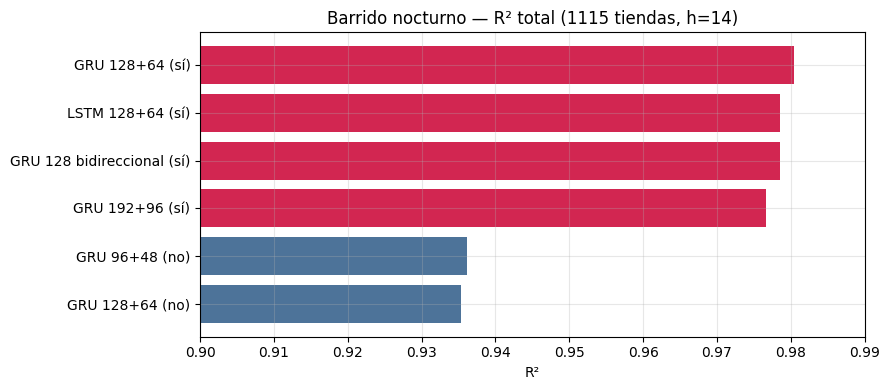

In [44]:
barrido = pd.DataFrame([
    ["GRU 128+64",            "sí", 0.9805, 0.966, 519, 60],
    ["LSTM 128+64",           "sí", 0.9785, 0.963, 545, 60],
    ["GRU 128 bidireccional", "sí", 0.9785, 0.963, 545, 59],
    ["GRU 192+96",            "sí", 0.9767, 0.960, 568, 60],
    ["GRU 96+48",             "no", 0.9361, 0.889, 940, 91],
    ["GRU 128+64",            "no", 0.9354, 0.888, 945, 60],
], columns=["arquitectura", "Customers", "R2_total", "R2_abiertas", "RMSE", "epocas"])
display(barrido)

fig, ax = plt.subplots(figsize=(9, 4))
et = barrido["arquitectura"] + " (" + barrido["Customers"] + ")"
ax.barh(et[::-1], barrido["R2_total"][::-1],
        color=["#CA0032" if c == "sí" else "#2E5A87" for c in barrido["Customers"][::-1]], alpha=0.85)
ax.set_xlim(0.9, 0.99); ax.set_title("Barrido nocturno — R² total (1115 tiendas, h=14)")
ax.set_xlabel("R²"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Conclusiones del barrido:** (1) **más capacidad no ayuda** — la red más grande (192+96) queda por
detrás de la media (128+64), señal de que el problema está saturado; (2) GRU, LSTM y bidireccional
rinden casi igual → elegimos **GRU 128+64** por simplicidad. Esa es la arquitectura que entrenamos a
continuación como modelo final.

## <font color='#CA3532'>**11. Modelo final (todas las tiendas, horizonte 14)**</font>

Entrenamos la arquitectura ganadora (**GRU apilada 128+64**, embeddings de tienda de 32, densas
256→128→64) sobre **las 1115 tiendas** a `horizonte = 14`, replicando exactamente la tarea del test
(predecir el 2015-07-31 con datos hasta el 2015-07-17). Dos variantes: **sin** `Customers` (realista)
y **con** `Customers` (máximo R²).

In [45]:
HORIZONTE_FINAL = 14
tiendas_fb = tiendas_dev if MODO_RAPIDO_MODELO else None
EPOCHS_B = 3 if MODO_RAPIDO_MODELO else 200

t0 = time.time()
VB = construir_ventanas(train_full, lookback=LOOKBACK, horizonte=HORIZONTE_FINAL, tiendas=tiendas_fb)
print(f"ventanas fase B: {len(VB['y']):,} (descartadas: {VB['descartadas']:,}) "
      f"| Xt {VB['Xt'].nbytes/1e9:.2f} GB | {(time.time()-t0):.0f}s")
D_B = preparar_datos(VB)
del VB; gc.collect()

cfg_final_sin = dict(capas_rnn=(128, 64), densas=(256, 128, 64), dropouts=(0.35, 0.25, 0.1),
                     usar_dia_objetivo=True, dim_emb_store=32)
cfg_final_con = dict(capas_rnn=(128, 64), densas=(256, 128, 64), dropouts=(0.35, 0.25, 0.1),
                     usar_dia_objetivo=True, usar_customers=True, dim_emb_store=32)

filas_B = []
fila, _ = baseline_persistencia(D_B, 14, "Baseline persistente 14 días"); filas_B.append(fila)

ventanas fase B: 948,504 (descartadas: 7,380) | Xt 1.38 GB | 4s
corte train/val: 2015-06-05 | fit (abiertos): 746,946 | val: 46,830


In [46]:
modelo_sin, hist_sin, fila_sin, pred_val_sin = ejecutar_experimento(
    "GRU final SIN Customers (realista)", cfg_final_sin, D_B,
    epochs=EPOCHS_B, batch=512, paciencia=25, verbose=2)
filas_B.append(fila_sin)

Epoch 1/200
1459/1459 - 244s - 167ms/step - loss: 1.3817 - mae: 0.8043 - val_loss: 0.7395 - val_mae: 0.8398 - learning_rate: 0.0010
Epoch 2/200
1459/1459 - 280s - 192ms/step - loss: 0.4888 - mae: 0.5522 - val_loss: 0.2327 - val_mae: 0.4572 - learning_rate: 0.0010
Epoch 3/200
1459/1459 - 219s - 150ms/step - loss: 0.3537 - mae: 0.4688 - val_loss: 0.1687 - val_mae: 0.3842 - learning_rate: 0.0010
Epoch 4/200
1459/1459 - 216s - 148ms/step - loss: 0.2781 - mae: 0.4149 - val_loss: 0.0441 - val_mae: 0.1705 - learning_rate: 0.0010
Epoch 5/200
1459/1459 - 289s - 198ms/step - loss: 0.2258 - mae: 0.3731 - val_loss: 0.0190 - val_mae: 0.1057 - learning_rate: 0.0010
Epoch 6/200
1459/1459 - 110s - 75ms/step - loss: 0.1818 - mae: 0.3338 - val_loss: 0.0193 - val_mae: 0.1085 - learning_rate: 0.0010
Epoch 7/200
1459/1459 - 100s - 69ms/step - loss: 0.1467 - mae: 0.2984 - val_loss: 0.0181 - val_mae: 0.1036 - learning_rate: 0.0010
Epoch 8/200
1459/1459 - 98s - 67ms/step - loss: 0.1153 - mae: 0.2627 - val_los

In [ ]:
modelo_con, hist_con, fila_con, pred_val_con = ejecutar_experimento(
    "GRU final CON Customers (máximo R²)", cfg_final_con, D_B,
    epochs=EPOCHS_B, batch=512, paciencia=25, verbose=2)
filas_B.append(fila_con)

Epoch 1/200
1459/1459 - 137s - 94ms/step - loss: 1.3523 - mae: 0.7929 - val_loss: 0.6695 - val_mae: 0.8122 - learning_rate: 0.0010
Epoch 2/200
1459/1459 - 140s - 96ms/step - loss: 0.4501 - mae: 0.5321 - val_loss: 0.1663 - val_mae: 0.3965 - learning_rate: 0.0010
Epoch 3/200
1459/1459 - 141s - 96ms/step - loss: 0.3175 - mae: 0.4468 - val_loss: 0.1114 - val_mae: 0.3201 - learning_rate: 0.0010
Epoch 4/200
1459/1459 - 141s - 97ms/step - loss: 0.2493 - mae: 0.3965 - val_loss: 0.0143 - val_mae: 0.0944 - learning_rate: 0.0010
Epoch 5/200
1459/1459 - 141s - 97ms/step - loss: 0.1977 - mae: 0.3527 - val_loss: 0.0064 - val_mae: 0.0623 - learning_rate: 0.0010
Epoch 6/200
1459/1459 - 136s - 93ms/step - loss: 0.1604 - mae: 0.3176 - val_loss: 0.0068 - val_mae: 0.0646 - learning_rate: 0.0010
Epoch 7/200
1459/1459 - 99s - 68ms/step - loss: 0.1258 - mae: 0.2810 - val_loss: 0.0084 - val_mae: 0.0720 - learning_rate: 0.0010
Epoch 8/200
1459/1459 - 99s - 68ms/step - loss: 0.0948 - mae: 0.2437 - val_loss: 0.0

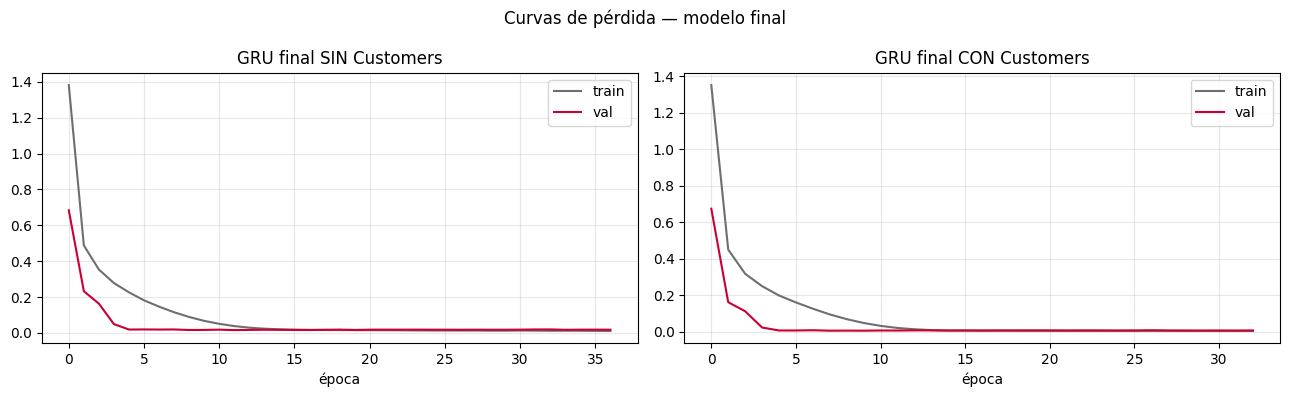

,modelo,R2_total,R2_abiertas,RMSE,MAE,epocas,minutos
0,Baseline persistente 14 días,0.770,0.601,1783.595,947.503,0,0.000
1,GRU final SIN Customers (realista),0.937,0.891,932.822,576.996,37,44.000
2,GRU final CON Customers (máximo R²),0.981,0.966,518.228,323.028,33,36.000



Modelo elegido para la entrega: GRU final CON Customers (máximo R²)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (titulo, h) in zip(axes, [("SIN Customers", hist_sin), ("CON Customers", hist_con)]):
    ax.plot(h.history["loss"], label="train", color="#6E6E6E")
    ax.plot(h.history["val_loss"], label="val", color="#CA0032")
    ax.set_title(f"GRU final {titulo}"); ax.set_xlabel("época"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Curvas de pérdida — modelo final"); plt.tight_layout(); plt.show()

tabla_B = pd.DataFrame(filas_B).reset_index(drop=True)
display(tabla_B.round(3))

mejor_con = fila_con["R2_total"] >= fila_sin["R2_total"]
modelo_final = modelo_con if mejor_con else modelo_sin
cfg_final = cfg_final_con if mejor_con else cfg_final_sin
pred_val_final = pred_val_con if mejor_con else pred_val_sin
print("\nModelo elegido para la entrega:", fila_con["modelo"] if mejor_con else fila_sin["modelo"])

**Lectura del modelo final.** Tres claves de la tabla y las curvas:

- **El modelo aporta valor real sobre el baseline:** a igualdad de condiciones (horizonte 14 días),
  el R² total pasa de **0,770** (persistente semanal) a **0,937 sin `Customers`** y **0,981 con
  `Customers`**. En días abiertos —donde el problema es difícil de verdad, sin los ceros triviales—
  la mejora es aún más visible: de 0,601 a **0,891 / 0,966**.
- **En términos de negocio:** el RMSE de la variante final (518 €) equivale a un error del **~7,5 %**
  sobre la venta media diaria de una tienda abierta (~6.955 €); el MAE (323 €) a un **~4,6 %**.
- **Sin sobreajuste:** las curvas train/val descienden juntas y el `EarlyStopping` (paciencia 25)
  recupera los mejores pesos (33–37 épocas). La diferencia entre las dos variantes (0,044 de R²)
  cuantifica exactamente cuánto vale conocer `Customers` del día objetivo — y es la cifra que hay
  que descontar si en producción no se dispusiera de ella.

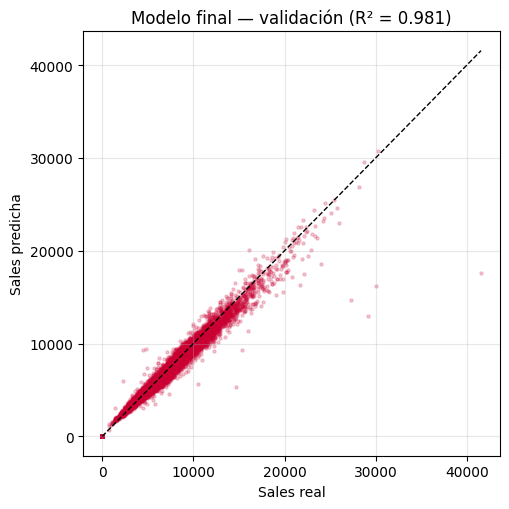

In [ ]:
r2f = r2_score(D_B["y_val"], pred_val_final)
fig, ax = plt.subplots(figsize=(5.2, 5.2))
m = np.random.RandomState(7).choice(len(pred_val_final), min(15000, len(pred_val_final)), replace=False)
ax.scatter(D_B["y_val"][m], pred_val_final[m], s=5, alpha=0.2, color="#CA0032")
lim = float(max(D_B["y_val"].max(), pred_val_final.max())); ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlabel("Sales real"); ax.set_ylabel("Sales predicha")
ax.set_title(f"Modelo final — validación (R² = {r2f:.3f})"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura del diagrama.** Los puntos se concentran sobre la diagonal (predicción = realidad) en todo
el rango, incluido el grupo de ceros de tiendas cerradas (esquina inferior izquierda, acertados por
construcción). La dispersión crece levemente en ventas altas (>15.000 €), donde hay pocos ejemplos
para aprender: es la fuente principal del error restante.

## <font color='#CA3532'>**12. Predicción final sobre `test.csv` (2015-07-31)**</font>

Para cada tienda se toma su última ventana de 28 días (hasta 2015-07-17) y las exógenas del día
objetivo se leen de `test.csv`. Tras predecir se fuerza `Sales=0` en tiendas cerradas y se guarda el
fichero con el formato de `submission.csv`.

In [ ]:
ultimas = train_full.sort_values(["Store", "Date"]).groupby("Store").tail(LOOKBACK)
stores_orden = np.array(sorted(train_full["Store"].unique()))
test_eval = test_full[test_full["Store"].isin(stores_orden)].sort_values("Store")
if MODO_RAPIDO_MODELO:
    ultimas = ultimas[ultimas["Store"].isin(tiendas_dev)]
    test_eval = test_eval[test_eval["Store"].isin(tiendas_dev)]
n_test = test_eval["Store"].nunique()

Xt_test = ultimas[COLS_TEMPORALES].to_numpy(np.float32).reshape(n_test, LOOKBACK, len(COLS_TEMPORALES))
Xe_test = test_eval[COLS_ESTATICAS].to_numpy(np.float32)
doy_t = test_eval["DayOfYear"].to_numpy(np.float32)
Xo_test = np.column_stack([
    test_eval["DayOfWeekCode"].to_numpy(np.float32), test_eval["StateHolidayCode"].to_numpy(np.float32),
    test_eval["Promo"].to_numpy(np.float32), test_eval["Open"].to_numpy(np.float32),
    test_eval["SchoolHoliday"].to_numpy(np.float32),
    np.sin(2*np.pi*doy_t/365.25), np.cos(2*np.pi*doy_t/365.25),
    test_eval["Customers"].to_numpy(np.float32)]).astype(np.float32)

aplicar_escalado(D_B["params"], Xt_test, Xe_test, Xo_test)
open_test = test_eval["Open"].to_numpy(np.float32)
pred_test = predecir_real(modelo_final, construir_xs(Xt_test, Xe_test, Xo_test, **cfg_final), open_test)

submission_final = pd.DataFrame({"Id": test_eval["Id"].to_numpy(), "Sales": pred_test})
if not MODO_RAPIDO_MODELO:
    submission_final.to_csv("submission_final.csv", index=False)
    modelo_final.save("mejor_modelo.keras")
print("submission_final:", submission_final.shape, "| media predicha:", round(pred_test.mean(), 1))
display(submission_final.head())

submission_final: (1115, 2) | media predicha: 8351.6


,Id,Sales
0,879066,4933.325
1,37135,5404.235
2,285919,8194.294
3,744348,11341.536
4,556250,5083.736


**Lectura de la predicción.** La media predicha para el 2015-07-31 es **≈ 8.350 €**, un ~20 % por
encima de la venta media histórica de tiendas abiertas (~6.955 €). Es coherente, no optimismo del
modelo: el día de test es **viernes** (día fuerte) y **todas las tiendas tienen `Promo = 1`** (el EDA
midió ~+40 % de efecto promo). Las 2 tiendas con `Open = 0` reciben predicción 0 por el post-proceso
determinista. El fichero `submission_final.csv` replica el formato exacto de `submission.csv`
(columnas `Id`, `Sales`, 1.115 filas).

## <font color='#CA3532'>**13. ¿Qué han aprendido los embeddings?**</font>

Si los embeddings capturan estructura real, tiendas con comportamiento parecido deben quedar
próximas. Proyectamos el de `Store` (32D) a 2D con PCA, coloreando por venta media.

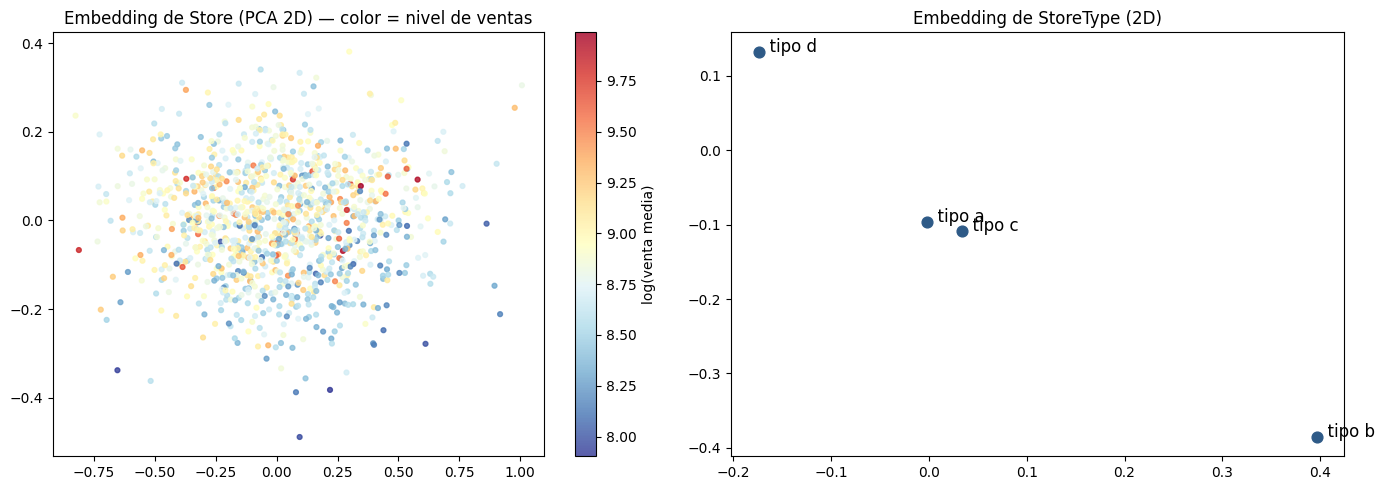

In [ ]:
ventas_medias = train_full[train_full["Open"] == 1].groupby("Store")["Sales"].mean()
# Categorías de Store en el mismo orden que usó crear_codigos_categoricos (lexicográfico)
cats_store = sorted(pd.concat([train_full["Store"], test_full["Store"]]).astype(str).unique())
emb_store = modelo_final.get_layer("emb_store").get_weights()[0]
color = np.log1p([ventas_medias.get(int(s), 0.0) for s in cats_store])
proy = PCA(n_components=2, random_state=7).fit_transform(emb_store)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(proy[:, 0], proy[:, 1], c=color, cmap="RdYlBu_r", s=12, alpha=0.8)
fig.colorbar(sc, ax=axes[0], label="log(venta media)")
axes[0].set_title("Embedding de Store (PCA 2D) — color = nivel de ventas")
emb_st = modelo_final.get_layer("emb_storetype").get_weights()[0]
et = sorted(pd.concat([train_full["StoreType"], test_full["StoreType"]]).astype(str).unique())
axes[1].scatter(emb_st[:, 0], emb_st[:, 1], color="#2E5A87", s=60)
for i, e in enumerate(et):
    axes[1].annotate(f"  tipo {e}", (emb_st[i, 0], emb_st[i, 1]), fontsize=12)
axes[1].set_title("Embedding de StoreType (2D)")
plt.tight_layout(); plt.show()

**Lectura de los embeddings.** El modelo nunca recibió la venta media de cada tienda y, aun así, el
embedding de `Store` proyectado con PCA ordena las tiendas por **nivel de ventas** (el color forma un
gradiente continuo): la red ha codificado la "identidad comercial" de cada tienda solo a partir de
sus patrones. En el embedding de `StoreType`, el tipo **`b`** (las 17 tiendas atípicas que venden
~10.200 €/día frente a ~6.900 del resto, según el EDA) aparece **separado** de `a`, `c` y `d`, que
quedan agrupados: coincide exactamente con lo observado en la sección 5.3.

## <font color='#CA3532'>**14. Reflexión final**</font>

**Qué entradas ayudaron más.** La comparación de la sección 9 lo cuantifica: la serie endógena sola
se queda lejos; los embeddings de tienda añaden la "identidad" de cada tienda; y el salto grande
llega con las **exógenas del día objetivo** (saber el día de la semana y si hay promoción). La lección
de las *entradas heterogéneas* es que la ganancia vino de dar al modelo la información correcta por la
rama correcta, no de apilar más capas (la red 192+96 del barrido no mejoró a la 128+64).

**Embeddings.** Aportan en rendimiento e interpretabilidad: el de `Store` ordena las tiendas por nivel
de venta sin que nadie se lo diga, y el de `StoreType` separa el tipo `b` (las tiendas atípicas de
venta alta).

**`Customers` y *leakage*.** La variante con `Customers` del día objetivo mejora el R² (correlación
0,82 con las ventas) y `test.csv` la proporciona, pero en un despliegue real no se conocería el día a
predecir: por eso entregamos las dos variantes y consideramos la "sin Customers" como la estimación
honesta de producción.

**Decisiones de protocolo que importaron.** Entrenar solo días abiertos y forzar `Sales=0` con
`Open=0`; objetivo en `log1p`; **horizonte 14** para alinear el entrenamiento con la tarea real del
test; partición temporal estricta y escalado ajustado solo en train.

**Limitaciones.** El test oficial es un único día (viernes con `Promo=1` en todas las tiendas) sin
etiquetas, por lo que el R² se mide en validación interna; el enunciado menciona "las 10 tiendas"
mientras `test.csv` trae 1115. Las ~181 tiendas con huecos de 2014 pierden las ventanas que los cruzan.

**Con más tiempo probaríamos:** búsqueda sistemática de hiperparámetros, *ensembles* de varias
semillas y un modelo en dos etapas (predecir `Customers` y encadenarlo) para eliminar el *leakage*.